Author: Derrick Chen (format based on a project by Anna Phyo & Derrick Chen)


Date: 06/15/2026

Modified Date: 07/31/2026

Description: This file contains the fully functional codes to train a data center environmental impact predicting model using Linear, Ridge and Lasso Regressors, AdaBoost, Gradient Booster, Stochastic Gradient Descent (SGD) Regressor, Linear Support Vector Regression (SVR), Artificial Neural Network (ANN)/Multi-Layer Perceptrion (MLP), Random Forest and XGBoost Regressor. This previously attempted to use multi-output regression before shifting to 2 single output regressions. Code includes data fitting, training, and results analysis.

1. Importing the File

In [ ]:
import pandas as pd
import numpy as np

# Mounting the Drive
from google.colab import drive
drive.mount('/content/drive')

# Pathing to my file
file = "/content/drive/MyDrive/data_center_hybrid.csv"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


2. Reading the File

In [ ]:
df = pd.read_csv(file)

3. Using Three Methods to Explore the Data

In [ ]:
df.head()

,Year,Facility_ID,City,Country,Facility_Type,Estimated_Capacity_MW,PUE,Cooling_System_Type,WUE_L_per_kWh,Daily_Electricity_Usage_MWh,Daily_Water_Usage_Gallons,Surrounding_Water_Stress_Tier
0,2019,DC-D2763E00,Madrid,Spain,Enterprise/Standard,6.24,1.975,Evaporative,1.481,183.62,36362.94,Low
1,2020,DC-D2763E00,Madrid,Spain,Enterprise/Standard,6.36,1.967,Evaporative,1.459,254.34,49833.60,Low
2,2021,DC-D2763E00,Madrid,Spain,Enterprise/Standard,6.47,1.928,Evaporative,1.450,266.85,53026.35,Low
3,2022,DC-D2763E00,Madrid,Spain,Enterprise/Standard,6.59,1.897,Evaporative,1.413,199.14,39198.30,Low
4,2023,DC-D2763E00,Madrid,Spain,Enterprise/Standard,6.70,1.869,Evaporative,1.389,225.94,44366.48,Low


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126770 entries, 0 to 126769
Data columns (total 12 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Year                           126770 non-null  int64  
 1   Facility_ID                    126770 non-null  object 
 2   City                           126770 non-null  object 
 3   Country                        126770 non-null  object 
 4   Facility_Type                  126770 non-null  object 
 5   Estimated_Capacity_MW          126770 non-null  float64
 6   PUE                            126770 non-null  float64
 7   Cooling_System_Type            126770 non-null  object 
 8   WUE_L_per_kWh                  126770 non-null  float64
 9   Daily_Electricity_Usage_MWh    126770 non-null  float64
 10  Daily_Water_Usage_Gallons      126770 non-null  float64
 11  Surrounding_Water_Stress_Tier  126770 non-null  object 
dtypes: float64(5), int64(1), objec

In [ ]:
df.describe()

,Year,Estimated_Capacity_MW,PUE,WUE_L_per_kWh,Daily_Electricity_Usage_MWh,Daily_Water_Usage_Gallons
count,126770.000000,126770.000000,126770.000000,126770.000000,126770.000000,1.267700e+05
mean,2022.000000,23.075117,1.637746,0.820596,605.222368,1.312182e+05
std,2.000008,45.847195,0.190833,0.925481,1040.061940,3.979629e+05
min,2019.000000,1.000000,1.057000,0.001000,22.190000,2.240100e+02
25%,2020.000000,5.450000,1.518000,0.139000,167.432500,4.840538e+03
50%,2022.000000,9.870000,1.643000,0.232000,302.750000,1.218130e+04
75%,2024.000000,14.180000,1.787000,1.654000,451.370000,7.573068e+04
max,2025.000000,562.890000,2.000000,3.000000,14812.660000,7.585092e+06


4. Plotting A Histogram for Each Numerical Attribute

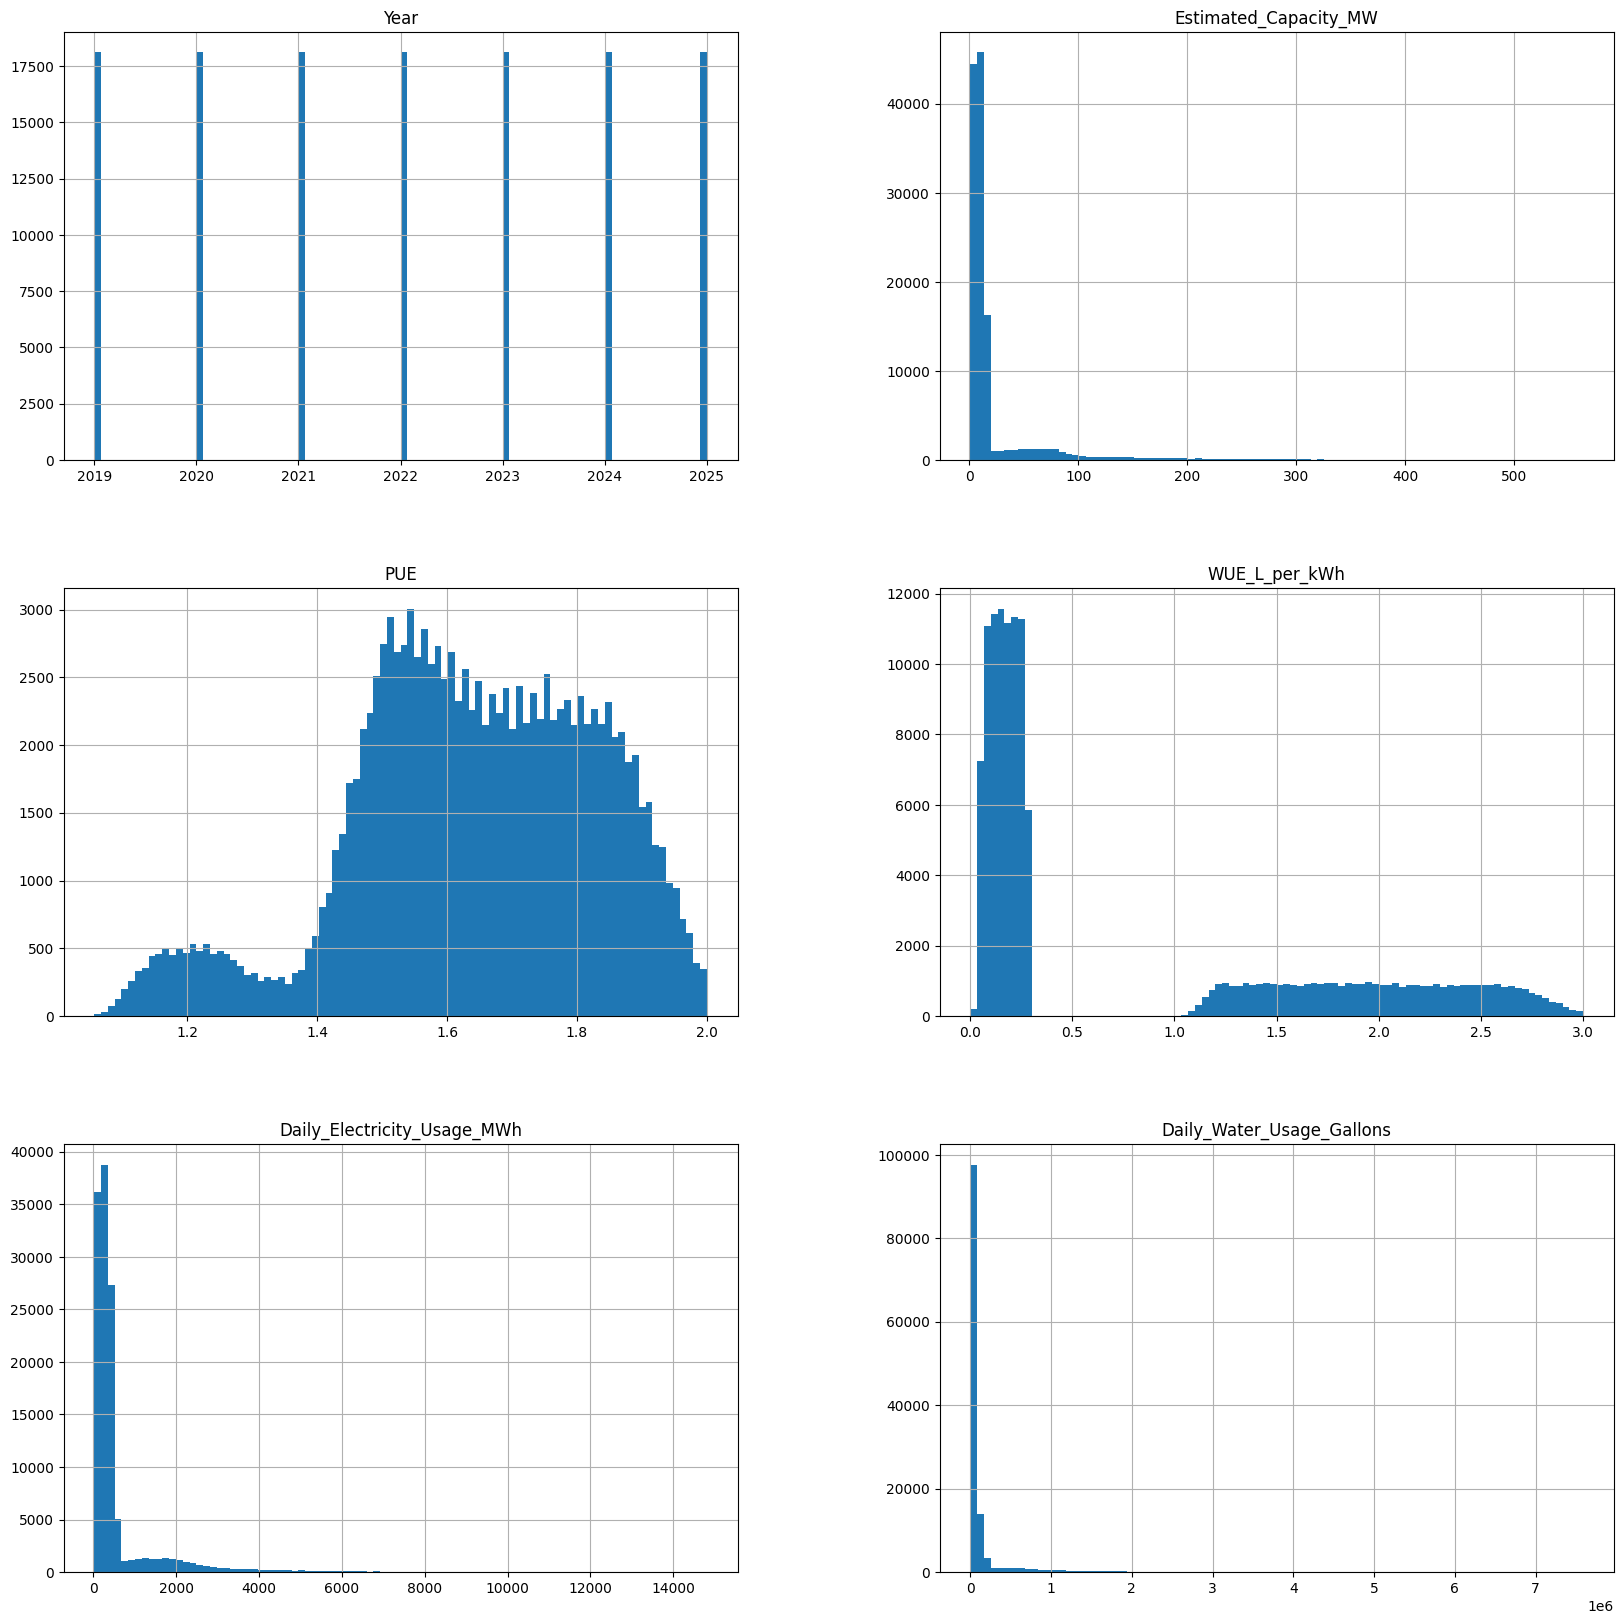

In [ ]:
import matplotlib.pyplot as plt

df.hist(bins=90, figsize=(20, 20))
plt.show()

Observations: Daily usage in both daily electric and water usages have massive spikes close to 0, before rapidly declining in comparison, similar trend with estimated capacity in MW. Power Usage Effectiveness (PUE) has a small increase near 0 and decreases again near 1.35, before rapidly increasing after 1.4, gradual decrease between 1.55 and 1.8 and sharp decline afterwards. Water Usage Effectiveness (WUE) has a massive spike between 0 and 0.3, then a relatively steady amount between 1 and 3.

5. Plotting the Feature Correlation Matrix

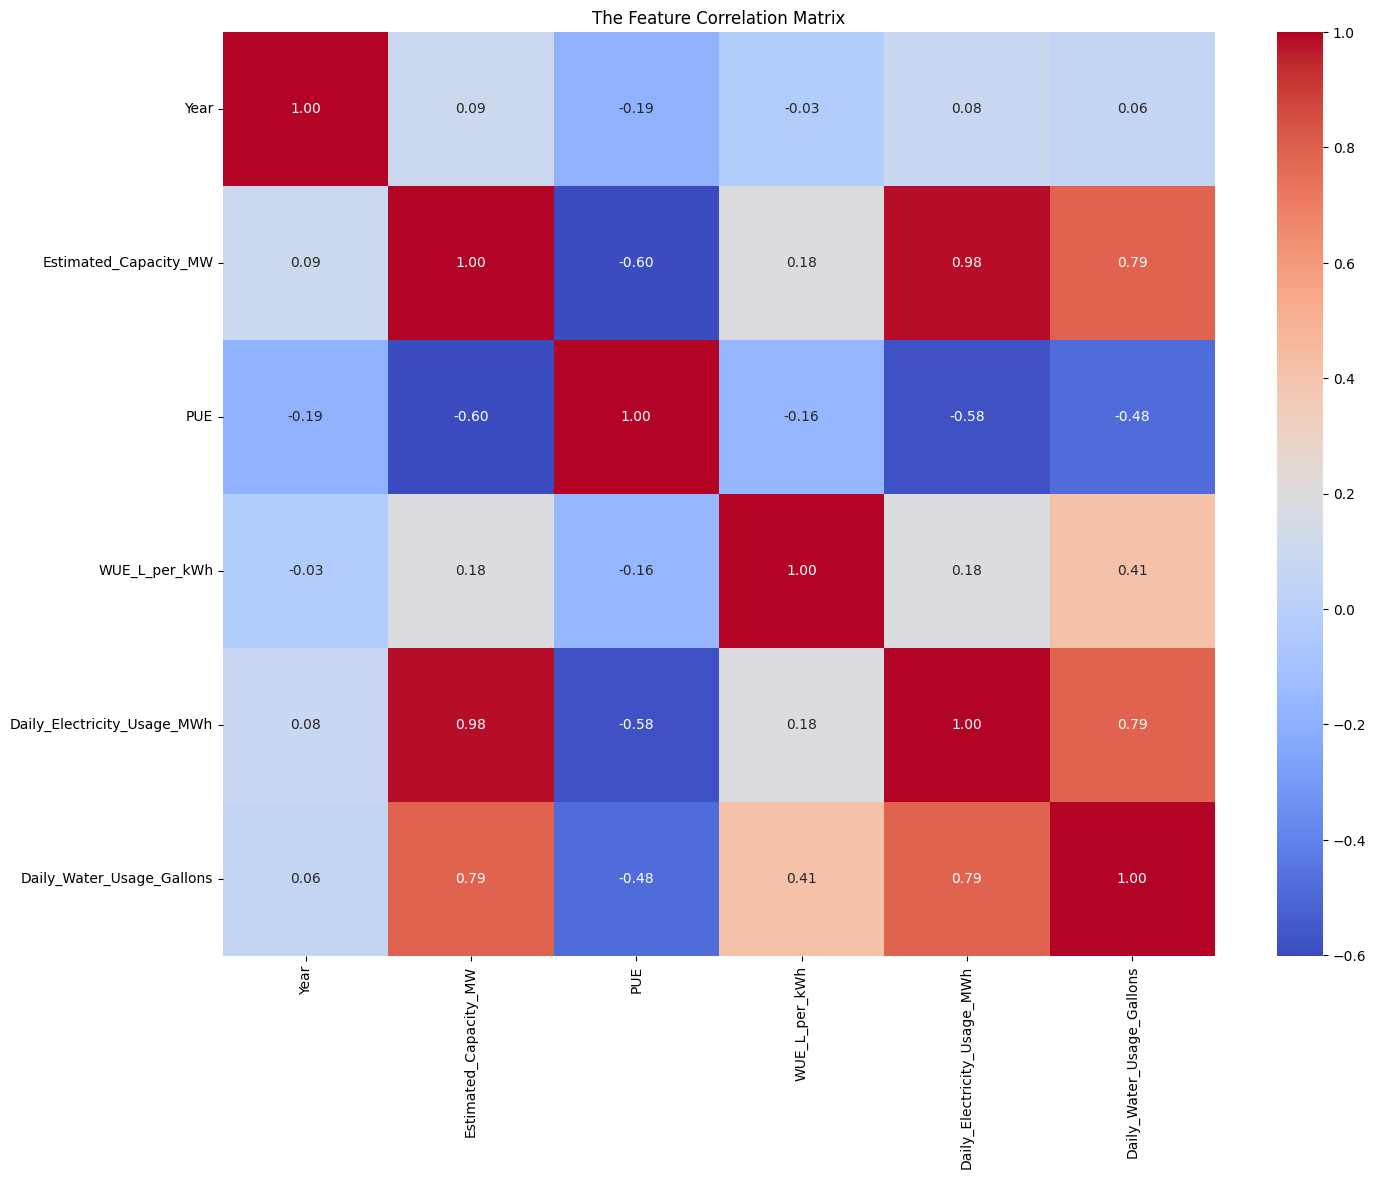

Correlations with Daily_Water_Usage_Gallons:
 Daily_Water_Usage_Gallons      1.000000
Daily_Electricity_Usage_MWh    0.791696
Estimated_Capacity_MW          0.791200
WUE_L_per_kWh                  0.413645
Year                           0.060377
PUE                           -0.484959
Name: Daily_Water_Usage_Gallons, dtype: float64
Correlations with Daily_Electricity_Usage_MWh:
 Daily_Electricity_Usage_MWh    1.000000
Estimated_Capacity_MW          0.983549
Daily_Water_Usage_Gallons      0.791696
WUE_L_per_kWh                  0.184339
Year                           0.083897
PUE                           -0.576587
Name: Daily_Electricity_Usage_MWh, dtype: float64

Top 5 positively correlated features with Daily_Water_Usage_Gallons:
Daily_Electricity_Usage_MWh    0.791696
Estimated_Capacity_MW          0.791200
WUE_L_per_kWh                  0.413645
Year                           0.060377
PUE                           -0.484959
Name: Daily_Water_Usage_Gallons, dtype: float64

Top 5 neg

In [ ]:
import seaborn as sns

# Keep only numeric columns
df_numeric = df.select_dtypes(include=['float64', 'int64'])

# Compute correlations
correlation_matrix = df_numeric.corr()

# Heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title("The Feature Correlation Matrix")
plt.show()

# Correlation with pm25_ugm3
target_corr = correlation_matrix['Daily_Water_Usage_Gallons'].sort_values(ascending=False)
print("Correlations with Daily_Water_Usage_Gallons:\n", target_corr)

# Correlation with no2_ugm3
target_corr2 = correlation_matrix['Daily_Electricity_Usage_MWh'].sort_values(ascending=False)
print("Correlations with Daily_Electricity_Usage_MWh:\n", target_corr2)

# Top 5 positive and negative correlations for Daily_Water_Usage_Gallons and Daily_Electricity_Usage_MWh
print("\nTop 5 positively correlated features with Daily_Water_Usage_Gallons:")
print(target_corr[1:6])  # skip self-correlation

print("\nTop 5 negatively correlated features with Daily_Water_Usage_Gallons:")
print(target_corr[-5:])

print("\nTop 5 positively correlated features with Daily_Electricity_Usage_MWh:")
print(target_corr2[1:6])  # skip self-correlation

print("\nTop 5 negatively correlated features with Daily_Electricity_Usage_MWh:")
print(target_corr2[-5:])

Observations:

Top positive correlations:

- Daily Water Usage has strong positive correlations with Daily Electricity Usage and Estimated Capacity, and has moderate positive correlation with Water Usage Effectiveness
-Daily Electricity Usage has strong positive correlations with Daily Water Usage and Estimated Capacity, and a weak positive correlation with WUE

Top negative correlations:
-Daily Water Usage has a moderate negative correlation with Power Usage Effectiveness and a weak poisitve correlation with year
-Daily Electricity Usage has a moderate negative correlation with Power Usage Effectiveness and a weak positive correlation with year


6. Sorting data by city, year and month

In [ ]:
df = df.sort_values(['Facility_ID', 'Year'])
df.head()

,Year,Facility_ID,City,Country,Facility_Type,Estimated_Capacity_MW,PUE,Cooling_System_Type,WUE_L_per_kWh,Daily_Electricity_Usage_MWh,Daily_Water_Usage_Gallons,Surrounding_Water_Stress_Tier
17066,2019,DC-0006E5D5,Giza,Egypt,Enterprise/Standard,5.06,1.555,Evaporative,1.644,147.79,41287.35,Low
17067,2020,DC-0006E5D5,Giza,Egypt,Enterprise/Standard,5.13,1.545,Evaporative,1.626,128.47,35730.38,Low
17068,2021,DC-0006E5D5,Giza,Egypt,Enterprise/Standard,5.21,1.542,Evaporative,1.601,138.09,37880.51,Low
17069,2022,DC-0006E5D5,Giza,Egypt,Enterprise/Standard,5.29,1.522,Evaporative,1.558,149.30,40376.15,Low
17070,2023,DC-0006E5D5,Giza,Egypt,Enterprise/Standard,5.37,1.512,Evaporative,1.527,176.09,46981.17,Low


7. Creating Lag Features, Growth Rate Features, Rolling Averages and Rolling Standard Deviation

In [ ]:
# 1-year lag features
df['Water_Lag1'] = (df.groupby('Facility_ID')['Daily_Water_Usage_Gallons'].shift(1))
df['Electricity_Lag1'] = (df.groupby('Facility_ID')['Daily_Electricity_Usage_MWh'].shift(1))

# 2-year lag features
df['Water_Lag2'] = (df.groupby('Facility_ID')['Daily_Water_Usage_Gallons'].shift(2))
df['Electricity_Lag2'] = (df.groupby('Facility_ID')['Daily_Electricity_Usage_MWh'].shift(2))

# Year-over-year changes
df['Water_Growth'] = (df.groupby('Facility_ID')['Daily_Water_Usage_Gallons'].pct_change())
df['Electricity_Growth'] = (df.groupby('Facility_ID')['Daily_Electricity_Usage_MWh'].pct_change())

# Remove rows where lag values don't exist
df = df.dropna().reset_index(drop=True)

print(df.shape)
df.head()

(0, 26)


,Year,Facility_ID,City,Country,Facility_Type,Estimated_Capacity_MW,PUE,Cooling_System_Type,WUE_L_per_kWh,Daily_Electricity_Usage_MWh,...,Electricity_Growth,Water_Growth,Electricity_Growth_Pct,Water_Growth_Pct,Electricity_Rolling3,Water_Rolling3,Electricity_STD3,Water_STD3,Electricity_Delta,Water_Delta


In [ ]:
#Growth Rate Features year over year
df['Water_Growth'] = (df.groupby('Facility_ID')['Daily_Water_Usage_Gallons'].pct_change())
df['Electricity_Growth'] = (df.groupby('Facility_ID')['Daily_Electricity_Usage_MWh'].pct_change())

# Convert to percentages instead of decimals
df['Water_Growth_Pct'] = df['Water_Growth'] * 100
df['Electricity_Growth_Pct'] = df['Electricity_Growth'] * 100

df[['Facility_ID','Year','Electricity_Growth','Water_Growth']].head()

,Facility_ID,Year,Electricity_Growth,Water_Growth
0,DC-0006E5D5,2025,NaN,NaN
1,DC-00072FB6,2025,NaN,NaN
2,DC-00091E2F,2025,NaN,NaN
3,DC-00108D19,2025,NaN,NaN
4,DC-0013C6B0,2025,NaN,NaN


In [ ]:
#3 Year Rolling Averages
df['Water_Rolling3'] = (df.groupby('Facility_ID')['Daily_Water_Usage_Gallons'].transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean()))
df['Electricity_Rolling3'] = (df.groupby('Facility_ID')['Daily_Electricity_Usage_MWh'].transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean()))

In [ ]:
#Rolling Standard Deviations
df['Water_STD3'] = (df.groupby('Facility_ID')['Daily_Water_Usage_Gallons'].transform(lambda x: x.shift(1).rolling(3, min_periods=1).std()))
df['Electricity_STD3'] = (df.groupby('Facility_ID')['Daily_Electricity_Usage_MWh'].transform(lambda x: x.shift(1).rolling(3, min_periods=1).std()))

In [ ]:
#Difference from last year
df['Water_Delta'] = (df.groupby('Facility_ID')['Daily_Water_Usage_Gallons'].diff())
df['Electricity_Delta'] = (df.groupby('Facility_ID')['Daily_Electricity_Usage_MWh'].diff())

In [ ]:
#Remove missing rows
df = df.dropna().reset_index(drop=True)

8. Splitting Datasets into Training, Validation and Test Sets

In [ ]:
train_df = df[df["Year"] == 2023]
val_df = df[df["Year"] == 2024]
test_df = df[df["Year"] > 2024]

9. Separating Features and Target

In [ ]:
# Features (drop both target columns)
X_train = train_df.drop(columns=['Daily_Water_Usage_Gallons', 'Daily_Electricity_Usage_MWh'])

X_val = val_df.drop(columns=['Daily_Water_Usage_Gallons', 'Daily_Electricity_Usage_MWh'])

X_test = test_df.drop(columns=['Daily_Water_Usage_Gallons', 'Daily_Electricity_Usage_MWh'])

X_train = X_train.drop(columns=['Facility_ID', 'Facility_Name', 'Owner_Company', 'City', 'Country'], errors='ignore')
X_val = X_val.drop(columns=['Facility_ID', 'Facility_Name', 'Owner_Company', 'City', 'Country'], errors='ignore')
X_test = X_test.drop(columns=['Facility_ID', 'Facility_Name', 'Owner_Company', 'City', 'Country'], errors='ignore')

# Water target
y_train_water = train_df['Daily_Water_Usage_Gallons']
y_val_water = val_df['Daily_Water_Usage_Gallons']
y_test_water = test_df['Daily_Water_Usage_Gallons']

# Electricity target
y_train_elec = train_df['Daily_Electricity_Usage_MWh']
y_val_elec = val_df['Daily_Electricity_Usage_MWh']
y_test_elec = test_df['Daily_Electricity_Usage_MWh']

# Check the shapes
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)
print("y_train water:", y_train_water.shape)
print("y_val water:", y_val_water.shape)
print("y_test water:", y_test_water.shape)
print("y_train elec:", y_train_elec.shape)
print("y_val elec:", y_val_elec.shape)
print("y_test elec:", y_test_elec.shape)

X_train: (18110, 21)
X_val: (18110, 21)
X_test: (18110, 21)
y_train water: (18110,)
y_val water: (18110,)
y_test water: (18110,)
y_train elec: (18110,)
y_val elec: (18110,)
y_test elec: (18110,)


Note 7/17/2026 paraphrasing AI:
The Country and City colums were removed prior to model training because they had many useless and malformed values (e.g., postal codes, street addresses, and partial location names) and exhibited very high cardinality (344 and 2,513 unique values respectively). One-hot encoding these columns would have produced thousands of sparse features with little predictive value while increasing model complexity and instability.

10. Checking Whether the Training Set Has the Correct Features

In [ ]:
print(X_train.columns)

Index(['Year', 'Facility_Type', 'Estimated_Capacity_MW', 'PUE',
       'Cooling_System_Type', 'WUE_L_per_kWh', 'Surrounding_Water_Stress_Tier',
       'Electricity_Lag1', 'Water_Lag1', 'Electricity_Lag2', 'Water_Lag2',
       'Electricity_Growth', 'Water_Growth', 'Electricity_Growth_Pct',
       'Water_Growth_Pct', 'Electricity_Rolling3', 'Water_Rolling3',
       'Electricity_STD3', 'Water_STD3', 'Electricity_Delta', 'Water_Delta'],
      dtype='object')


11. Scaling Features for Linear & Lasso Regressors, SGD Regressor, Linear Support Vector Regression (SVR), and Artificial Neural Network (MLP Regressor)

In [ ]:
from sklearn.preprocessing import StandardScaler

# Identify categorical columns
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns

# Apply one-hot encoding
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_val_encoded = pd.get_dummies(X_val, columns=categorical_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Align columns - crucial for consistent feature sets after one-hot encoding
# This ensures that X_val_encoded and X_test_encoded have the same columns as X_train_encoded
X_val_encoded = X_val_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

# Initialize the scaler
scaler = StandardScaler()

# Scale the features
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_val_scaled = scaler.transform(X_val_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

12. Training the Model Using the Linear Regression to Handle Linear Relationships

In [ ]:
import sklearn

#water
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr_model_water = LinearRegression()
lr_model_water.fit(X_train_scaled, y_train_water)

# Predictions
train_pred_lr_water = lr_model_water.predict(X_train_scaled)
val_pred_lr_water = lr_model_water.predict(X_val_scaled)
test_pred_lr_water = lr_model_water.predict(X_test_scaled)

print("Linear Regression trained successfully.")
lr_mae_water = mean_absolute_error(y_test_water, test_pred_lr_water)
lr_rmse_water = np.sqrt(mean_squared_error(y_test_water, test_pred_lr_water))
lr_r2_water = r2_score(y_test_water, test_pred_lr_water)

print(f"Train MAE:  {mean_absolute_error(y_train_water, train_pred_lr_water):.4f}")
print(f"Validation MAE:  {mean_absolute_error(y_val_water, val_pred_lr_water):.4f}")
print(f"Test MAE:  {lr_mae_water:.4f}")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train_water, train_pred_lr_water)):.4f}")
print(f"Validation RMSE: {np.sqrt(mean_squared_error(y_val_water, val_pred_lr_water)):.4f}")
print(f"Test RMSE: {lr_rmse_water:.4f}")
print(f"Train R squared:   {r2_score(y_train_water, train_pred_lr_water):.4f}")
print(f"Validation R squared:   {r2_score(y_val_water, val_pred_lr_water):.4f}")
print(f"Test R squared:   {lr_r2_water:.4f}")

Linear Regression trained successfully.
Train MAE:  0.0000
Validation MAE:  3007.8665
Test MAE:  3489.7597
Train RMSE: 0.0000
Validation RMSE: 12361.4289
Test RMSE: 14911.5646
Train R squared:   1.0000
Validation R squared:   0.9994
Test R squared:   0.9993


Observations:
The R squared values are good but the MAE and RMSE's are all really high, which would indicate terrible results if the range was small. The Training scores are near perfect but the absurdly high MAE and RMSE's for validation and test indicate severe overfitting

In [ ]:
#electricity
lr_model_elec = LinearRegression()
lr_model_elec.fit(X_train_scaled, y_train_elec)

# Predictions
train_pred_lr_elec = lr_model_elec.predict(X_train_scaled)
val_pred_lr_elec = lr_model_elec.predict(X_val_scaled)
test_pred_lr_elec = lr_model_elec.predict(X_test_scaled)

lr_mae_elec = mean_absolute_error(y_test_elec, test_pred_lr_elec)
lr_rmse_elec = np.sqrt(mean_squared_error(y_test_elec, test_pred_lr_elec))
lr_r2_elec = r2_score(y_test_elec, test_pred_lr_elec)

print("Linear Regression trained successfully.")
print(f"Train MAE:  {mean_absolute_error(y_train_elec, train_pred_lr_elec):.4f}")
print(f"Validation MAE:  {mean_absolute_error(y_val_elec, val_pred_lr_elec):.4f}")
print(f"Test MAE:  {lr_mae_elec:.4f}")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train_elec, train_pred_lr_elec)):.4f}")
print(f"Validation RMSE: {np.sqrt(mean_squared_error(y_val_elec, val_pred_lr_elec)):.4f}")
print(f"Test RMSE: {lr_rmse_elec:.4f}")
print(f"Train R squared:   {r2_score(y_train_elec, train_pred_lr_elec):.4f}")
print(f"Validation R squared:   {r2_score(y_val_elec, val_pred_lr_elec):.4f}")
print(f"Test R squared:   {lr_r2_elec:.4f}")

Linear Regression trained successfully.
Train MAE:  0.0000
Validation MAE:  13.2459
Test MAE:  14.8941
Train RMSE: 0.0000
Validation RMSE: 36.1719
Test RMSE: 43.5442
Train R squared:   1.0000
Validation R squared:   0.9992
Test R squared:   0.9992


Observations:
This has a pretty similar trend to the water regression with near perftect training scores and good R squared scores, but high MAE and RMSE's for validation and test suggesting overfitting; however they are much lower than their water counterparts

Linear Regression Optimization (Ridge + Grid Search)

In [ ]:
#water
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Hyperparameters to test
lrO_grid = {'alpha': [0.01, 0.1, 1, 10, 100]}

# Grid Search
ridge_water_search = GridSearchCV(Ridge(), lrO_grid, cv=5, scoring='r2', n_jobs=-1)

ridge_water_search.fit(X_train_scaled, y_train_water)

# Best model
best_ridge_water = ridge_water_search.best_estimator_

print("Best alpha:", ridge_water_search.best_params_)

Best alpha: {'alpha': 0.01}


In [ ]:
y_pred_ridge_water = best_ridge_water.predict(X_test_scaled)

# Metrics
ridge_water_mae = mean_absolute_error(y_test_water, y_pred_ridge_water)
ridge_water_rmse = np.sqrt(mean_squared_error(y_test_water, y_pred_ridge_water))
ridge_water_r2 = r2_score(y_test_water, y_pred_ridge_water)

print(f"MAE : {ridge_water_mae:.2f}")
print(f"RMSE: {ridge_water_rmse:.2f}")
print(f"R squared: {ridge_water_r2:.4f}")

MAE : 3489.73
RMSE: 14910.08
R squared: 0.9993


Observations:
Optimization still resulted in ridiculously high MAE and RMSE, which further confirms that either linear regression isn't good for this dataset or the values are huge and the values are actually good. Also the differences are minimal which suggest ridge and gridsearch have little effect on this dataset

In [ ]:
#electricity
#Hyperparameters are the same as before
# Grid Search
ridge_elec_search = GridSearchCV(Ridge(), lrO_grid, cv=5, scoring='r2', n_jobs=-1)

ridge_elec_search.fit(X_train_scaled, y_train_elec)

# Best model
best_ridge_elec = ridge_elec_search.best_estimator_

print("Best alpha:", ridge_elec_search.best_params_)

Best alpha: {'alpha': 0.01}


In [ ]:
y_pred_ridge_elec = best_ridge_elec.predict(X_test_scaled)

# Metrics
ridge_elec_mae = mean_absolute_error(y_test_elec, y_pred_ridge_elec)
ridge_elec_rmse = np.sqrt(mean_squared_error(y_test_elec, y_pred_ridge_elec))
ridge_elec_r2 = r2_score(y_test_elec, y_pred_ridge_elec)

print(f"MAE : {ridge_elec_mae:.2f}")
print(f"RMSE: {ridge_elec_rmse:.2f}")
print(f"R²  : {ridge_elec_r2:.4f}")

MAE : 14.89
RMSE: 43.54
R²  : 0.9992


Observations: The electricity model had mostly the same trend but with much lower MAE and RMSE, I think this will be a trend across models

Training the AdaBoosting Regressor

In [ ]:
from sklearn.ensemble import AdaBoostRegressor

water_ada_model = AdaBoostRegressor(random_state=42)

# Train model
water_ada_model.fit(X_train_encoded, y_train_water)

print("AdaBoost model trained.")

AdaBoost model trained.


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predictions
y_pred_ada_water = water_ada_model.predict(X_test_encoded)

# Metrics
ada_mae_water = mean_absolute_error(y_test_water, y_pred_ada_water)
ada_rmse_water = np.sqrt(mean_squared_error(y_test_water, y_pred_ada_water))
ada_r2_water = r2_score(y_test_water, y_pred_ada_water)

print(f"MAE : {ada_mae_water:.2f}")
print(f"RMSE: {ada_rmse_water:.2f}")
print(f"R2  : {ada_r2_water:.4f}")

MAE : 96896.18
RMSE: 125422.70
R2  : 0.9508


In [ ]:
#electricity
elec_ada_model = AdaBoostRegressor(random_state=42)

# Train model
elec_ada_model.fit(X_train_encoded, y_train_elec)

print("AdaBoost model trained.")

AdaBoost model trained.


In [ ]:
# Predictions
y_pred_ada_elec = elec_ada_model.predict(X_test_encoded)

# Metrics
ada_mae_elec = mean_absolute_error(y_test_elec, y_pred_ada_elec)
ada_rmse_elec = np.sqrt(mean_squared_error(y_test_elec, y_pred_ada_elec))
ada_r2_elec = r2_score(y_test_elec, y_pred_ada_elec)

print(f"MAE : {ada_mae_elec:.2f}")
print(f"RMSE: {ada_rmse_elec:.2f}")
print(f"R squared : {ada_r2_elec:.4f}")

MAE : 178.24
RMSE: 314.75
R squared : 0.9557


Observations: I believe the water RMSE's being very high are due to the sheer variance of the values so there's a good chance that they're actually pretty accurate after all in relation to the data. The same goes for electricity but to a lesser extent, which makes sense due to the variance of water and electricity used in data centers

Predicting Residuals

In [ ]:
train_residual_pred_water = water_ada_model.predict(X_train_encoded)
val_residual_pred_water = water_ada_model.predict(X_val_encoded)
test_residual_pred_water = water_ada_model.predict(X_test_encoded)
train_residual_pred_elec = elec_ada_model.predict(X_train_encoded)
val_residual_pred_elec = elec_ada_model.predict(X_val_encoded)
test_residual_pred_elec = elec_ada_model.predict(X_test_encoded)

Training the GradientBoosting Regressor

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gbr_water = GradientBoostingRegressor(random_state=42)

# Train
gbr_water.fit(X_train_encoded, y_train_water)

print("Gradient Boosting (Water) trained.")

Gradient Boosting (Water) trained.


In [ ]:
water_gbr_pred = gbr_water.predict(X_test_encoded)

gbr_mae_water = mean_absolute_error(y_test_water, water_gbr_pred)
gbr_rmse_water = np.sqrt(mean_squared_error(y_test_water, water_gbr_pred))
gbr_r2_water = r2_score(y_test_water, water_gbr_pred)

print("MAE: ", gbr_mae_water)
print("RMSE: ", gbr_rmse_water)
print("R squared: ", gbr_r2_water)

MAE:  10893.961215654012
RMSE:  57024.48006142593
R squared:  0.9898349214588732


In [ ]:
gbr_elec = GradientBoostingRegressor(random_state=42)

gbr_elec.fit(X_train_encoded, y_train_elec)

print("Gradient Boosting (Electricity) trained.")

Gradient Boosting (Electricity) trained.


In [ ]:
elec_gbr_pred = gbr_elec.predict(X_test_encoded)

gbr_mae_elec = mean_absolute_error(y_test_elec, elec_gbr_pred)
gbr_rmse_elec = np.sqrt(mean_squared_error(y_test_elec, elec_gbr_pred))
gbr_r2_elec = r2_score(y_test_elec, elec_gbr_pred)

print("MAE: ", gbr_mae_elec)
print("RMSE: ", gbr_rmse_elec)
print("R squared: ", gbr_r2_elec)

MAE:  48.8381239056756
RMSE:  200.58010629948507
R squared:  0.9819917353359101


Observations:
I have decided to primarily focus on R squared values since those are likely the most accurate way to measure quality given the wide range of values in teh dataset. Without optimization this got very high R squared scores at above 0.98, which is really good.

Optimized GradientBoost with RandomSearchCV

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
#Water
water_gbr_param_grid = {'n_estimators': [100, 150], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 4], 'subsample': [0.8, 1.0]}

gbr_grid_water = RandomizedSearchCV(GradientBoostingRegressor(random_state=42), water_gbr_param_grid, n_iter=6, cv=2, scoring='r2', n_jobs=-1, random_state=42)

gbr_grid_water.fit(X_train_encoded, y_train_water)

best_gbr_water = gbr_grid_water.best_estimator_

print(gbr_grid_water.best_params_)

{'subsample': 0.8, 'n_estimators': 150, 'max_depth': 4, 'learning_rate': 0.1}


In [ ]:
gbrO_water_pred = gbr_water.predict(X_test_encoded)

gbrO_mae_water = mean_absolute_error(y_test_water, gbrO_water_pred)
gbrO_rmse_water = np.sqrt(mean_squared_error(y_test_water, gbrO_water_pred))
gbrO_r2_water = r2_score(y_test_water, gbrO_water_pred)

print("Gradient Boosting - Water")

print("MAE :", gbrO_mae_water)
print("RMSE:", gbrO_rmse_water)
print("R squared:", gbrO_r2_water)

Gradient Boosting - Water
MAE : 10893.961215654012
RMSE: 57024.48006142593
R squared: 0.9898349214588732


In [ ]:
#Electricity
elec_gbr_param_grid = {'n_estimators': [100, 150], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 4], 'subsample': [0.8, 1.0]}

gbr_grid_elec = RandomizedSearchCV(GradientBoostingRegressor(random_state=42), water_gbr_param_grid, n_iter=6, cv=2, scoring='r2', n_jobs=-1, random_state=42)

gbr_grid_elec.fit(X_train_encoded, y_train_elec)

best_gbr_elec = gbr_grid_elec.best_estimator_

print(gbr_grid_elec.best_params_)

{'subsample': 0.8, 'n_estimators': 150, 'max_depth': 4, 'learning_rate': 0.1}


In [ ]:
gbrO_elec_pred = gbr_elec.predict(X_test_encoded)

gbrO_mae_elec = mean_absolute_error(y_test_elec, gbrO_elec_pred)
gbrO_rmse_elec = np.sqrt(mean_squared_error(y_test_elec, gbrO_elec_pred))
gbrO_r2_elec = r2_score(y_test_elec, gbrO_elec_pred)

print("Gradient Boosting - Electricity")

print("MAE:", gbrO_mae_elec)
print("RMSE:", gbrO_rmse_elec)
print("R squared :", gbrO_r2_elec)

Gradient Boosting - Electricity
MAE: 48.8381239056756
RMSE: 200.58010629948507
R squared : 0.9819917353359101


Observations: The optimized Gradient Boosting with RandomSearchCV achieved lower MAE and RMSE scores and a strong R squared, indicating a stronger fit to the training data. However, the run times were pretty long even with smaller parameter meant to shorten it, so that might not be ideal

Plotting the Model Comparison

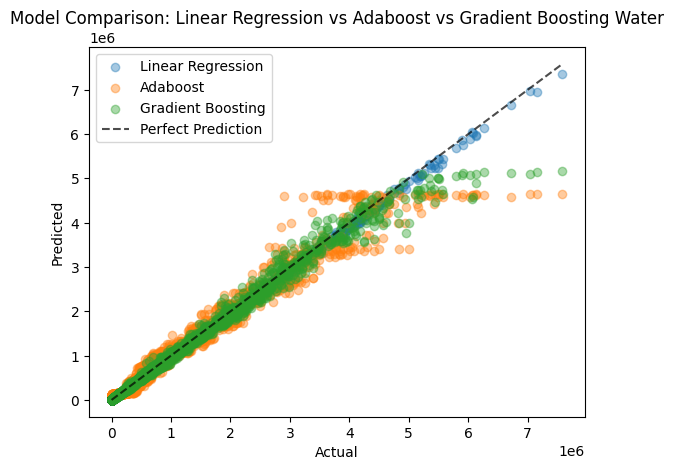

In [ ]:
# Scatter plots for Linear Regression, Adaboost, and Gradient Boosting for Water
plt.scatter(y_test_water, test_pred_lr_water, alpha=0.4, label="Linear Regression")
plt.scatter(y_test_water, y_pred_ada_water, alpha=0.4, label="Adaboost")
plt.scatter(y_test_water, gbrO_water_pred, alpha=0.4, label="Gradient Boosting")

# Perfect prediction line
min_val = min(y_test_water.min(), test_pred_lr_water.min(), y_pred_ada_water.min(), gbrO_water_pred.min())
max_val = max(y_test_water.max(), test_pred_lr_water.max(), y_pred_ada_water.max(), gbrO_water_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.7, label="Perfect Prediction")

plt.legend()
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Model Comparison: Linear Regression vs Adaboost vs Gradient Boosting Water")
plt.show()

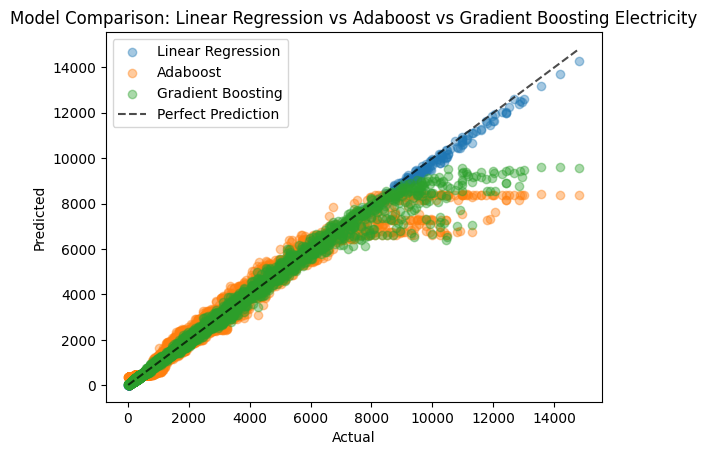

In [ ]:
# Scatter plots for Linear Regression, Adaboost, and Gradient Boosting for Electricity
plt.scatter(y_test_elec, test_pred_lr_elec, alpha=0.4, label="Linear Regression")
plt.scatter(y_test_elec, y_pred_ada_elec, alpha=0.4, label="Adaboost")
plt.scatter(y_test_elec, gbrO_elec_pred, alpha=0.4, label="Gradient Boosting")

# Perfect prediction line
min_val = min(y_test_elec.min(), test_pred_lr_elec.min(), y_pred_ada_elec.min(), gbrO_elec_pred.min())
max_val = max(y_test_elec.max(), test_pred_lr_elec.max(), y_pred_ada_elec.max(), gbrO_elec_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.7, label="Perfect Prediction")

plt.legend()
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Model Comparison: Linear Regression vs Adaboost vs Gradient Boosting Electricity")
plt.show()

Observations:
Both water and electricity have similar trends for Linear Regression, Adaboost, and Gradient Boosting, wit hteh latter two getting slightly lower than the actual predictions with larger values but being very close with smaller values. Linear Regression has the smallest variance, and these graphs make me think that these MAE and RMSE values are pretty good for the data ranges

13. Training the Model Using the Lasso Regression to Featuring Selections

In [ ]:
#water
from sklearn.linear_model import Lasso

lasso_water = Lasso(alpha=0.01, max_iter=20000)
lasso_water.fit(X_train_scaled, y_train_water)

train_pred_lasso_water = lasso_water.predict(X_train_scaled)
val_pred_lasso_water = lasso_water.predict(X_val_scaled)
test_pred_lasso_water = lasso_water.predict(X_test_scaled)

In [ ]:
lasso_water_pred = lasso_water.predict(X_test_scaled)

lasso_mae_water = mean_absolute_error(y_test_water, lasso_water_pred)
lasso_rmse_water = np.sqrt(mean_squared_error(y_test_water, lasso_water_pred))
lasso_r2_water = r2_score(y_test_water, lasso_water_pred)

print("Lasso Regression - Water")

print("MAE :", lasso_mae_water)
print("RMSE:", lasso_rmse_water)
print("R squared:", lasso_r2_water)

Lasso Regression - Water
MAE : 3081.001655767192
RMSE: 9564.904169547282
R squared: 0.9997140110082167


In [ ]:
#Electricity

lasso_elec = Lasso(alpha=0.01, max_iter=20000)
lasso_elec.fit(X_train_scaled, y_train_elec)

train_pred_lasso_elec = lasso_elec.predict(X_train_scaled)
val_pred_lasso_elec = lasso_elec.predict(X_val_scaled)
test_pred_lasso_elec = lasso_elec.predict(X_test_scaled)

In [ ]:
lasso_elec_pred = lasso_elec.predict(X_test_scaled)

lasso_mae_elec = mean_absolute_error(y_test_elec, lasso_elec_pred)
lasso_rmse_elec = np.sqrt(mean_squared_error(y_test_elec, lasso_elec_pred))
lasso_r2_elec = r2_score(y_test_elec, lasso_elec_pred)

print("Lasso Regression - Electrcity")

print("MAE :", lasso_mae_elec)
print("RMSE:", lasso_rmse_elec)
print("R squared:", lasso_r2_elec)

Lasso Regression - Electrcity
MAE : 0.32895105062419455
RMSE: 1.0747104253145625
R squared: 0.9999994830136529


Observations: Lasso regression has a near perfect R squared score, which makes me excited because I thought I was doing something wrong this entire time but I was doing things right

Lasso Regression Optimization (Alpha Tuning)

In [ ]:
#Water
# Different alpha values to test
lasso_param_grid = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]}

print("Lasso Regression Hyperparameter Tuning Water\n")

lasso_water_search = GridSearchCV(estimator=Lasso(max_iter=10000, random_state=42), param_grid=lasso_param_grid, cv=5, scoring='r2', n_jobs=-1)

# Train
lasso_water_search.fit(X_train_scaled, y_train_water)

# Best model
best_lasso_water = lasso_water_search.best_estimator_

print("Best Water Parameters:")
print(lasso_water_search.best_params_)
print("Best CV R squared:", lasso_water_search.best_score_)

Lasso Regression Hyperparameter Tuning Water

Best Water Parameters:
{'alpha': 0.1}
Best CV R squared: 0.9999982661168634


In [ ]:
lasso_search_water_pred = best_lasso_water.predict(X_test_scaled)

lassoO_mae_water = mean_absolute_error(y_test_water, lasso_search_water_pred)
lassoO_rmse_water = np.sqrt(mean_squared_error(y_test_water, lasso_search_water_pred))
lassoO_r2_water = r2_score(y_test_water, lasso_search_water_pred)

# Metrics
print("Optimized Lasso - Water")
print(f"MAE : {lassoO_mae_water}")
print(f"RMSE: {lassoO_rmse_water:.2f}")
print(f"R squared: {lassoO_r2_water:.4f}")

Optimized Lasso - Water
MAE : 3080.3693076707114
RMSE: 9563.23
R squared: 0.9997


In [ ]:
#Electricity
print("Lasso Regression Hyperparameter Tuning Electricity\n")

lasso_elec_search = GridSearchCV(estimator=Lasso(max_iter=10000, random_state=42), param_grid=lasso_param_grid, cv=5, scoring='r2', n_jobs=-1)

# Train
lasso_elec_search.fit(X_train_scaled, y_train_elec)

# Best model
best_lasso_elec = lasso_elec_search.best_estimator_

print("Best Electricity Parameters:")
print(lasso_elec_search.best_params_)
print("Best CV R squared:", lasso_elec_search.best_score_)

Lasso Regression Hyperparameter Tuning Electricity

Best Electricity Parameters:
{'alpha': 0.1}
Best CV R squared: 0.9999997747638492


In [ ]:
lasso_search_elec_pred = best_lasso_elec.predict(X_test_scaled)

lassoO_mae_elec = mean_absolute_error(y_test_elec, lasso_search_elec_pred)
lassoO_rmse_elec = np.sqrt(mean_squared_error(y_test_elec, lasso_search_elec_pred))
lassoO_r2_elec = r2_score(y_test_elec, lasso_search_elec_pred)

# Metrics
print("Optimized Lasso - Electricity")
print(f"MAE : {lassoO_mae_elec:.2f}")
print(f"RMSE: {lassoO_rmse_elec:.2f}")
print(f"R squared: {lassoO_r2_elec:.4f}")

Optimized Lasso - Electricity
MAE : 0.31
RMSE: 0.71
R squared: 1.0000


Observations:

Optimized Lasso Regressrion resulted in a nigh perfect R squared score for water and a perfect one for electricity, which indicates that lasso regression is a very good model for this dataset. However, it could be argued that this is too accurate as they seem really close to the actual values

Plotting the Lasso Standard vs Alpha Optimization

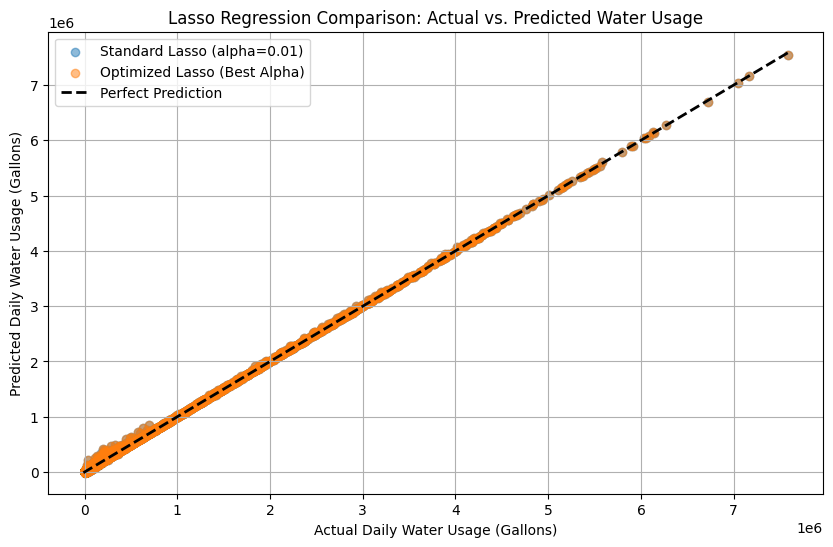

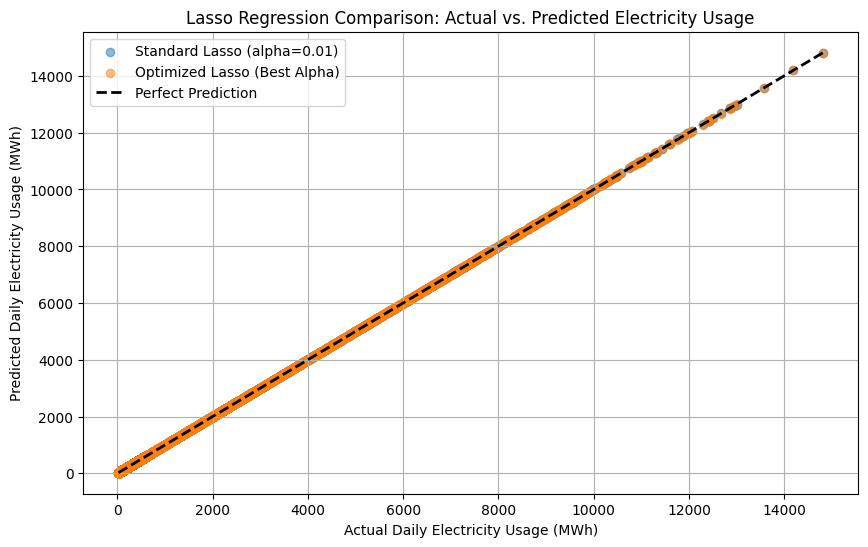

In [ ]:
# --- Water Consumption Comparison ---
plt.figure(figsize=(10, 6))
plt.scatter(y_test_water, test_pred_lasso_water, alpha=0.5, label='Standard Lasso (alpha=0.01)')
plt.scatter(y_test_water, lasso_search_water_pred, alpha=0.5, label='Optimized Lasso (Best Alpha)')

# Perfect prediction line
min_val_water = min(y_test_water.min(), test_pred_lasso_water.min(), lasso_search_water_pred.min())
max_val_water = max(y_test_water.max(), test_pred_lasso_water.max(), lasso_search_water_pred.max())
plt.plot([min_val_water, max_val_water], [min_val_water, max_val_water], 'k--', lw=2, label='Perfect Prediction')

plt.xlabel('Actual Daily Water Usage (Gallons)')
plt.ylabel('Predicted Daily Water Usage (Gallons)')
plt.title('Lasso Regression Comparison: Actual vs. Predicted Water Usage')
plt.legend()
plt.grid(True)
plt.show()

# --- Electricity Consumption Comparison ---
plt.figure(figsize=(10, 6))
plt.scatter(y_test_elec, test_pred_lasso_elec, alpha=0.5, label='Standard Lasso (alpha=0.01)')
plt.scatter(y_test_elec, lasso_search_elec_pred, alpha=0.5, label='Optimized Lasso (Best Alpha)')

# Perfect prediction line
min_val_elec = min(y_test_elec.min(), test_pred_lasso_elec.min(), lasso_search_elec_pred.min())
max_val_elec = max(y_test_elec.max(), test_pred_lasso_elec.max(), lasso_search_elec_pred.max())
plt.plot([min_val_elec, max_val_elec], [min_val_elec, max_val_elec], 'k--', lw=2, label='Perfect Prediction')

plt.xlabel('Actual Daily Electricity Usage (MWh)')
plt.ylabel('Predicted Daily Electricity Usage (MWh)')
plt.title('Lasso Regression Comparison: Actual vs. Predicted Electricity Usage')
plt.legend()
plt.grid(True)
plt.show()

Observations: Both versions of Lasso have very good results that are proportionally close to the predicted values, and I think that's good due to the high r squared values

14. Training the Model Using the Random Forest to Handle Complex and Non-linear Relationships

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Water
rf_water = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

rf_water.fit(X_train_encoded, y_train_water)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [ ]:
rf_water_pred = rf_water.predict(X_test_encoded)

rf_mae_water = mean_absolute_error(y_test_water, rf_water_pred)
rf_rmse_water = np.sqrt(mean_squared_error(y_test_water, rf_water_pred))
rf_r2_water = r2_score(y_test_water, rf_water_pred)

print("Random Forest - Water")
print(f"MAE : {rf_mae_water:.2f}")
print(f"RMSE: {rf_rmse_water:.2f}")
print(f"R squared: {rf_r2_water:.4f}")

Random Forest - Water
MAE : 8074.91
RMSE: 67224.00
R squared: 0.9859


In [ ]:
#Electricity
rf_elec = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

rf_elec.fit(X_train_encoded, y_train_elec)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [ ]:
rf_elec_pred = rf_elec.predict(X_test_encoded)

rf_mae_elec = mean_absolute_error(y_test_elec, rf_elec_pred)
rf_rmse_elec = np.sqrt(mean_squared_error(y_test_elec, rf_elec_pred))
rf_r2_elec = r2_score(y_test_elec, rf_elec_pred)

print("Random Forest - Electricity")
print(f"MAE : {rf_mae_elec:.2f}")
print(f"RMSE: {rf_rmse_elec:.2f}")
print(f"R squared: {rf_r2_elec:.4f}")

Random Forest - Electricity
MAE : 32.31
RMSE: 225.96
R squared: 0.9771


Observations: This model has solid performance, with a high R squared score even if it's not as good as other models like Lasso or Gradient Boosting

15. Training the Model Using the Stochastic Gradient Descent (SGD) Regressor

In [ ]:
#Water
from sklearn.linear_model import SGDRegressor

sgd_water = SGDRegressor(random_state=42, max_iter=1000, tol=1e-3)

sgd_water.fit(X_train_scaled, y_train_water)

SGDRegressor(random_state=42)

In [ ]:
sgd_water_pred = sgd_water.predict(X_test_scaled)

sgd_mae_water = mean_absolute_error(y_test_water, sgd_water_pred)
sgd_rmse_water = np.sqrt(mean_squared_error(y_test_water, sgd_water_pred))
sgd_r2_water = r2_score(y_test_water, sgd_water_pred)

print("SGD - Water")
print(f"MAE : {sgd_mae_water:.2f}")
print(f"RMSE: {sgd_rmse_water:.2f}")
print(f"R squared : {sgd_r2_water:.4f}")

SGD - Water
MAE : 3561.64
RMSE: 14697.04
R squared : 0.9993


In [ ]:
#Electricity
sgd_elec = SGDRegressor(random_state=42, max_iter=1000, tol=1e-3)

sgd_elec.fit(X_train_scaled, y_train_elec)

SGDRegressor(random_state=42)

In [ ]:
sgd_elec_pred = sgd_elec.predict(X_test_scaled)

sgd_mae_elec = mean_absolute_error(y_test_elec, sgd_elec_pred)
sgd_rmse_elec = np.sqrt(mean_squared_error(y_test_elec, sgd_elec_pred))
sgd_r2_elec = r2_score(y_test_elec, sgd_elec_pred)

print("SGD - Electricity")
print(f"MAE : {sgd_mae_elec:.2f}")
print(f"RMSE: {sgd_rmse_elec:.2f}")
print(f"R squared: {sgd_r2_elec:.4f}")

SGD - Electricity
MAE : 14.75
RMSE: 43.13
R squared: 0.9992


Observations: Unoptimized SGD has by far the worst performance so far, somehow with a huge negative R squared score that I didn't even know was possible

After removing the country column: This became one of the best performing models in terms of R squared. It's amazing how much junk data can affect training, because the difference is like night and day.

SGD Regressor Optimization (GridSearchSV)

In [ ]:
sgdO_param_grid = {'alpha': [0.0001, 0.001, 0.01], 'penalty': ['l2', 'elasticnet']}

grid_sgd_water = GridSearchCV(SGDRegressor(random_state=42, max_iter=5000, early_stopping=True), sgdO_param_grid, cv=3, scoring='r2', n_jobs=-1)

grid_sgd_water.fit(X_train_scaled, y_train_water)

best_sgd_water = grid_sgd_water.best_estimator_

print('Best Parameters:', grid_sgd_water.best_params_)
print('Best CV R squared:', grid_sgd_water.best_score_)

Best Parameters: {'alpha': 0.0001, 'penalty': 'elasticnet'}
Best CV R squared: 0.9991742707429103


In [ ]:
sgdO_water_pred = best_sgd_water.predict(X_test_scaled)

sgdO_mae_water = mean_absolute_error(y_test_water, sgdO_water_pred)
sgdO_rmse_water = np.sqrt(mean_squared_error(y_test_water, sgdO_water_pred))
sgdO_r2_water = r2_score(y_test_water, sgdO_water_pred)

print("Optimized SGD - Water")
print(f"MAE : {sgdO_mae_water:.2f}")
print(f"RMSE: {sgdO_rmse_water:.2f}")
print(f"R squared : {sgdO_r2_water:.4f}")

Optimized SGD - Water
MAE : 7228.41
RMSE: 18715.23
R squared : 0.9989


In [ ]:
grid_sgd_elec = GridSearchCV(SGDRegressor(random_state=42, max_iter=5000, early_stopping=True), sgdO_param_grid, cv=3, scoring='r2', n_jobs=-1)

grid_sgd_elec.fit(X_train_scaled, y_train_elec)

best_sgd_elec = grid_sgd_elec.best_estimator_

print('Best Parameters:', grid_sgd_elec.best_params_)
print('Best CV R squared:', grid_sgd_elec.best_score_)

Best Parameters: {'alpha': 0.0001, 'penalty': 'elasticnet'}
Best CV R squared: 0.9988587625862088


In [ ]:
sgdO_elec_pred = best_sgd_elec.predict(X_test_scaled)

sgdO_mae_elec = mean_absolute_error(y_test_elec, sgdO_elec_pred)
sgdO_rmse_elec = np.sqrt(mean_squared_error(y_test_elec, sgdO_elec_pred))
sgdO_r2_elec = r2_score(y_test_elec, sgdO_elec_pred)

print("Optimized SGD - Electricity")
print(f"MAE : {sgdO_mae_elec:.2f}")
print(f"RMSE: {sgdO_rmse_elec:.2f}")
print(f"R squared: {sgdO_r2_elec:.4f}")

Optimized SGD - Electricity
MAE : 20.86
RMSE: 46.18
R squared: 0.9990


Observations (before removing country column):

Hyperparameter tuning still resulted in terrible performance. I wasn't sure what exactly happened so I had to ask AI as to why the R squared value was so far into the negatives and it ultimately said the dataset was very skewed in terms of target distribution and SGD Regression doesn't perform well on that. Country column had a lot of noise including postal codes, businesses and street adresses and it should be dropped. Before this it said that "SGDRegressor was highly sensitive to the sparse one-hot encoded categorical features and the skewed target distribution. Despite optimization, it failed to converge to a useful solution, whereas other linear models (Linear Regression, Ridge, Lasso) and ensemble methods achieved strong predictive performance"

Observations (after removing country column): The country column was the root of everything, the skewed data did hinder things but this performance was very good

16. Training the Model Using Linear Support Vector Regression (SVR)

In [ ]:
from sklearn.svm import LinearSVR

svr_water = LinearSVR(random_state=42, max_iter=10000)

svr_water.fit(X_train_scaled, y_train_water)

print("Linear SVR Water model trained.")

Linear SVR Water model trained.


In [ ]:
water_pred_svr = svr_water.predict(X_test_scaled)

svr_mae_water = mean_absolute_error(y_test_water, water_pred_svr)
svr_rmse_water = np.sqrt(mean_squared_error(y_test_water, water_pred_svr))
svr_r2_water = r2_score(y_test_water, water_pred_svr)

print("Linear SVR - Water")
print(f"MAE : {svr_mae_water:.2f}")
print(f"RMSE: {svr_rmse_water:.2f}")
print(f"R squared: {svr_r2_water:.4f}")

Linear SVR - Water
MAE : 157125.12
RMSE: 566682.03
R squared: -0.0038


In [ ]:
svr_elec = LinearSVR(random_state=42, max_iter=10000)

svr_elec.fit(X_train_scaled, y_train_elec)

print("Linear SVR Electricity model trained.")

Linear SVR Electricity model trained.


In [ ]:
elec_pred_svr = svr_elec.predict(X_test_scaled)

svr_mae_elec = mean_absolute_error(y_test_elec, elec_pred_svr)
svr_rmse_elec = np.sqrt(mean_squared_error(y_test_elec, elec_pred_svr))
svr_r2_elec = r2_score(y_test_elec, elec_pred_svr)

print("Linear SVR - Electricity")
print(f"MAE : {svr_mae_elec:.2f}")
print(f"RMSE: {svr_rmse_elec:.2f}")
print(f"R squared: {svr_r2_elec:.4f}")

Linear SVR - Electricity
MAE : 14.52
RMSE: 41.53
R squared: 0.9992


Observations: The water model had very poor performance with a negative R squared, but the electricity model had a near perfect R squared, not sure what happened that resulted in such a big difference in quality

SVR Optimization (C and Epsilon)

In [ ]:
svr_param_grid = {'C': [0.1, 1, 10], 'epsilon': [0.0, 0.1, 0.5]}

grid_linear_svr_water = GridSearchCV(LinearSVR(random_state=42, max_iter=10000), param_grid=svr_param_grid, cv=3, scoring='r2', n_jobs=-1)

grid_linear_svr_water.fit(X_train_scaled, y_train_water)

best_linear_svr_water = grid_linear_svr_water.best_estimator_

print("Best Parameters:", grid_linear_svr_water.best_params_)
print("Best CV R squared:", grid_linear_svr_water.best_score_)

Best Parameters: {'C': 10, 'epsilon': 0.5}
Best CV R squared: 0.4062307150909487


In [ ]:
svrO_water_pred = best_linear_svr_water.predict(X_test_scaled)

svrO_mae_water = mean_absolute_error(y_test_water, svrO_water_pred)
svrO_rmse_water = np.sqrt(mean_squared_error(y_test_water, svrO_water_pred))
svrO_r2_water = r2_score(y_test_water, svrO_water_pred)

print("Optimized LinearSVR - Water")
print(f"MAE : {svrO_mae_water:.2f}")
print(f"RMSE: {svrO_rmse_water:.2f}")
print(f"R squared: {svrO_r2_water:.4f}")

Optimized LinearSVR - Water
MAE : 93365.97
RMSE: 369521.93
R squared: 0.5732


In [ ]:
grid_linear_svr_elec = GridSearchCV(LinearSVR(random_state=42, max_iter=10000), param_grid=svr_param_grid, cv=3, scoring='r2', n_jobs=-1)

grid_linear_svr_elec.fit(X_train_scaled, y_train_elec)

best_linear_svr_elec = grid_linear_svr_elec.best_estimator_

print("Best Parameters:", grid_linear_svr_elec.best_params_)
print("Best CV R squared:", grid_linear_svr_elec.best_score_)

Best Parameters: {'C': 10, 'epsilon': 0.0}
Best CV R squared: 0.9999999999950354


In [ ]:
svrO_elec_pred = best_linear_svr_elec.predict(X_test_scaled)

svrO_mae_elec = mean_absolute_error(y_test_elec, svrO_elec_pred)
svrO_rmse_elec = np.sqrt(mean_squared_error(y_test_elec, svrO_elec_pred))
svrO_r2_elec = r2_score(y_test_elec, svrO_elec_pred)

print("Optimized LinearSVR - Electricity")
print(f"MAE : {svrO_mae_elec:.2f}")
print(f"RMSE: {svrO_rmse_elec:.2f}")
print(f"R squared: {svrO_r2_elec:.4f}")

Optimized LinearSVR - Electricity
MAE : 14.89
RMSE: 43.54
R squared: 0.9992


Observations:

Hyperparameter tuning was applied to the Linear Support Vector Regression model using different values of C and epsilon. The best configuration (C = 10, epsilon = 0.5 for water and C = 10, epsilon = 0.0 for electricity)  had R squared values of 0.5732 and 0.9992 respectively, which is average at best for water but very good for electricity.

17. Training the Model Using the Artificial Neural Network (ANN), the  Multi-layer Perceptron (MLP) Regressor

In [ ]:
from sklearn.neural_network import MLPRegressor

ann_water = MLPRegressor(hidden_layer_sizes=(100, 50), activation='relu', solver='adam', learning_rate='adaptive', max_iter=1000, random_state=42)

ann_water.fit(X_train_scaled, y_train_water)

print("ANN (Water) trained.")

ANN (Water) trained.


In [ ]:
ann_water_pred = ann_water.predict(X_test_scaled)

ann_mae_water = mean_absolute_error(y_test_water, ann_water_pred)
ann_rmse_water = np.sqrt(mean_squared_error(y_test_water, ann_water_pred))
ann_r2_water = r2_score(y_test_water, ann_water_pred)

print("ANN - Water")
print(f"MAE : {ann_mae_water:.2f}")
print(f"RMSE: {ann_rmse_water:.2f}")
print(f"R squared: {ann_r2_water:.4f}")

ANN - Water
MAE : 3500.02
RMSE: 14134.07
R squared: 0.9994


In [ ]:
ann_elec = MLPRegressor(hidden_layer_sizes=(100, 50), activation='relu', solver='adam', learning_rate='adaptive', max_iter=1000, random_state=42)

ann_elec.fit(X_train_scaled, y_train_elec)

print("ANN (Electricity) trained.")

ANN (Electricity) trained.


In [ ]:
ann_elec_pred = ann_elec.predict(X_test_scaled)

ann_mae_elec = mean_absolute_error(y_test_elec, ann_elec_pred)
ann_rmse_elec = np.sqrt(mean_squared_error(y_test_elec, ann_elec_pred))
ann_r2_elec = r2_score(y_test_elec, ann_elec_pred)

print("ANN - Electricity")
print(f"MAE : {ann_mae_elec:.2f}")
print(f"RMSE: {ann_rmse_elec:.2f}")
print(f"R squared: {ann_r2_elec:.4f}")

ANN - Electricity
MAE : 13.97
RMSE: 40.76
R squared: 0.9993


Observations: The ANN also achieves a very good R squared score for both categories though it does take quite a while to run, which hinders performance overall.

18. Training model with XGBoost Regressor

In [ ]:
from xgboost import XGBRegressor

xgb_water = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, subsample=0.8, colsample_bytree=0.8, objective='reg:squarederror', random_state=42, n_jobs=-1)

xgb_water.fit(X_train_encoded, y_train_water)

print("XGBoost (Water) trained.")

XGBoost (Water) trained.


In [ ]:
xgb_water_pred = xgb_water.predict(X_test_encoded)

xgb_mae_water = mean_absolute_error(y_test_water, xgb_water_pred)
xgb_rmse_water = np.sqrt(mean_squared_error(y_test_water, xgb_water_pred))
xgb_r2_water = r2_score(y_test_water, xgb_water_pred)

print("XGBoost - Water")
print(f"MAE : {xgb_mae_water:.2f}")
print(f"RMSE: {xgb_rmse_water:.2f}")
print(f"R squared: {xgb_r2_water:.4f}")

XGBoost - Water
MAE : 9862.03
RMSE: 71353.34
R squared: 0.9841


In [ ]:
xgb_elec = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, subsample=0.8, colsample_bytree=0.8, objective='reg:squarederror', random_state=42, n_jobs=-1)

xgb_elec.fit(X_train_encoded, y_train_elec)

print("XGBoost (Electricity) trained.")

XGBoost (Electricity) trained.


In [ ]:
xgb_elec_pred = xgb_elec.predict(X_test_encoded)

xgb_mae_elec = mean_absolute_error(y_test_elec, xgb_elec_pred)
xgb_rmse_elec = np.sqrt(mean_squared_error(y_test_elec, xgb_elec_pred))
xgb_r2_elec = r2_score(y_test_elec, xgb_elec_pred)

print("XGBoost - Electricity")
print(f"MAE : {xgb_mae_elec:.2f}")
print(f"RMSE: {xgb_rmse_elec:.2f}")
print(f"R squared: {xgb_r2_elec:.4f}")

XGBoost - Electricity
MAE : 38.99
RMSE: 226.38
R squared: 0.9771


Observations:
XGBoost's good performance makes the high R squared values very consistent, even if it's slightly lower than multiple other models

XGBoost Optimized

In [ ]:
xgb_param_grid = {'n_estimators': [100, 200], 'max_depth': [4, 6], 'learning_rate': [0.05, 0.1]}

grid_xgb_water = GridSearchCV(XGBRegressor(objective='reg:squarederror', subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1) , xgb_param_grid, cv=3, scoring='r2', n_jobs=-1)

grid_xgb_water.fit(X_train_encoded, y_train_water)

best_xgb_water = grid_xgb_water.best_estimator_

print("Best Parameters:", grid_xgb_water.best_params_)
print("Best CV R squared:", grid_xgb_water.best_score_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200}
Best CV R squared: 0.9967950629141229


In [ ]:
xgbO_water_pred = best_xgb_water.predict(X_test_encoded)

xgbO_mae_water = mean_absolute_error(y_test_water, xgbO_water_pred)
xgbO_rmse_water = np.sqrt(mean_squared_error(y_test_water, xgbO_water_pred))
xgbO_r2_water = r2_score(y_test_water, xgbO_water_pred)

print("Optimized XGBoost - Water")
print(f"MAE : {xgbO_mae_water:.2f}")
print(f"RMSE: {xgbO_rmse_water:.2f}")
print(f"R squared: {xgbO_r2_water:.4f}")

Optimized XGBoost - Water
MAE : 10555.96
RMSE: 68188.81
R squared: 0.9855


In [ ]:
grid_xgb_elec = GridSearchCV(XGBRegressor(objective='reg:squarederror', subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1) , xgb_param_grid, cv=3, scoring='r2', n_jobs=-1)

grid_xgb_elec.fit(X_train_encoded, y_train_elec)

best_xgb_elec = grid_xgb_elec.best_estimator_

print("Best Parameters:", grid_xgb_elec.best_params_)
print("Best CV R squared:", grid_xgb_elec.best_score_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200}
Best CV R squared: 0.998039855616191


In [ ]:
xgbO_elec_pred = best_xgb_elec.predict(X_test_encoded)

xgbO_mae_elec = mean_absolute_error(y_test_elec, xgbO_elec_pred)
xgbO_rmse_elec = np.sqrt(mean_squared_error(y_test_elec, xgbO_elec_pred))
xgbO_r2_elec = r2_score(y_test_elec, xgbO_elec_pred)

print("Optimized XGBoost - Electricity")
print(f"MAE : {xgbO_mae_water:.2f}")
print(f"RMSE: {xgbO_rmse_water:.2f}")
print(f"R squared: {xgbO_r2_water:.4f}")

Optimized XGBoost - Electricity
MAE : 10555.96
RMSE: 68188.81
R squared: 0.9855


Observations:
XGBoost optimization resulted in slightly better performance but the difference isn't too noticable.

19. Plotting Random Forest, ANN, and XGBoost

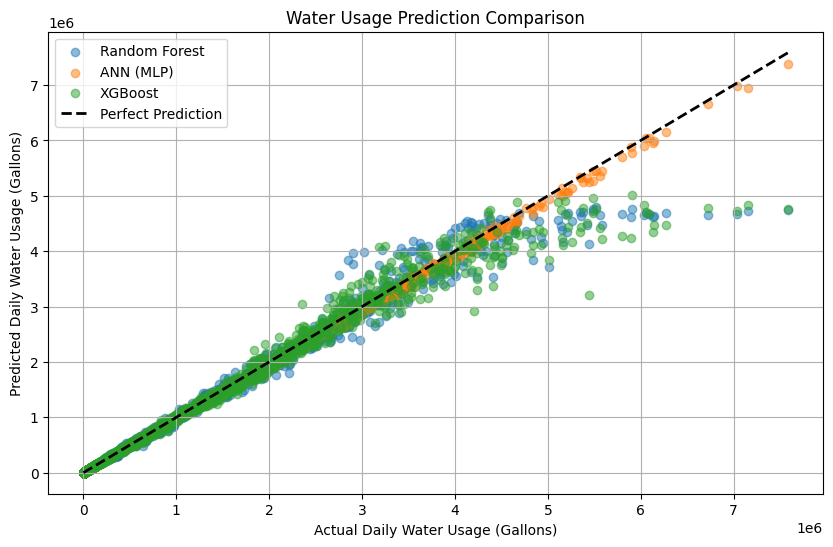

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(y_test_water, rf_water.predict(X_test_encoded), alpha=0.5, label='Random Forest')

plt.scatter(y_test_water, ann_water.predict(X_test_scaled), alpha=0.5, label='ANN (MLP)')

plt.scatter(y_test_water, xgb_water.predict(X_test_encoded), alpha=0.5, label='XGBoost')

# Perfect prediction line
min_val = min(y_test_water.min(), rf_water.predict(X_test_encoded).min(), ann_water.predict(X_test_scaled).min(), xgb_water.predict(X_test_encoded).min())

max_val = max(y_test_water.max(), rf_water.predict(X_test_encoded).max(), ann_water.predict(X_test_scaled).max(), xgb_water.predict(X_test_encoded).max())

plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Perfect Prediction')

plt.xlabel('Actual Daily Water Usage (Gallons)')
plt.ylabel('Predicted Daily Water Usage (Gallons)')
plt.title('Water Usage Prediction Comparison')
plt.legend()
plt.grid(True)

plt.show()

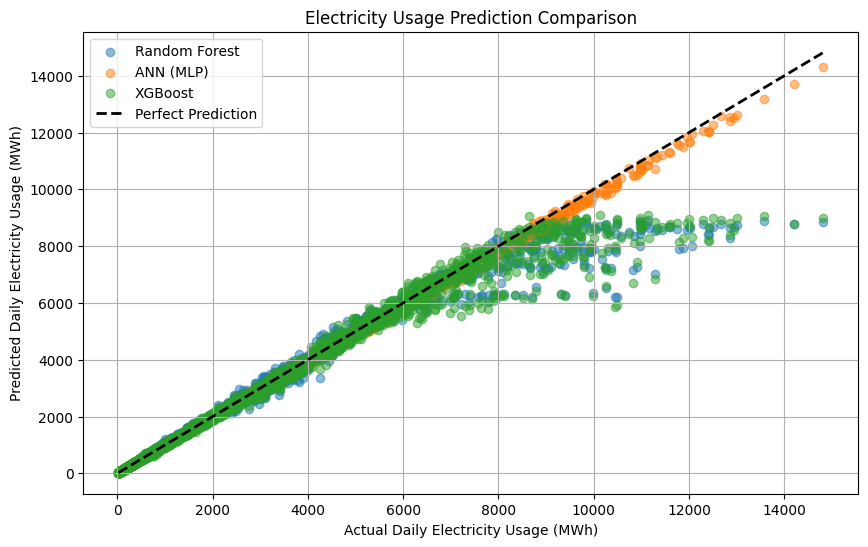

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(y_test_elec, rf_elec.predict(X_test_encoded), alpha=0.5, label='Random Forest')

plt.scatter( y_test_elec, ann_elec.predict(X_test_scaled), alpha=0.5, label='ANN (MLP)')

plt.scatter(y_test_elec, xgb_elec.predict(X_test_encoded), alpha=0.5, label='XGBoost')

# Perfect prediction line
min_val = min(y_test_elec.min(), rf_elec.predict(X_test_encoded).min(), ann_elec.predict(X_test_scaled).min(), xgb_elec.predict(X_test_encoded).min())

max_val = max(y_test_elec.max(), rf_elec.predict(X_test_encoded).max(), ann_elec.predict(X_test_scaled).max(), xgb_elec.predict(X_test_encoded).max())

plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Perfect Prediction')

plt.xlabel('Actual Daily Electricity Usage (MWh)')
plt.ylabel('Predicted Daily Electricity Usage (MWh)')
plt.title('Electricity Usage Prediction Comparison')
plt.legend()
plt.grid(True)

plt.show()

20. Calculating the Mean Water & Electricity and overall comparison chart

In [ ]:
mean_water = y_test_water.mean()
mean_elec = y_test_elec.mean()
print("Mean Water Usage:", mean_water)
print("Mean Electricity Usage:", mean_elec)

Mean Water Usage: 171863.50145554944
Mean Electricity Usage: 752.8512186637217


Table of Values for all models and show the best performing model

In [ ]:
#water
water_results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Ridge Regression (Optimized Linear)',
        'AdaBoost Regressor',
        'Gradient Boosting Regressor',
        'Optimized Gradient Boosting Regressor',
        'Lasso Regression',
        'Optimized Lasso Regression',
        'Random Forest Regressor',
        'SGD Regressor',
        'Optimized SGD Regressor',
        'Linear SVR',
        'Optimized Linear SVR',
        'ANN (MLP)',
        'XGBoost',
        'Optimized XGBoost'
    ],
    'MAE': [
        lr_mae_water,
        ridge_water_mae,
        ada_mae_water,
        gbr_mae_water,
        gbrO_mae_water,
        lasso_mae_water,
        lassoO_mae_water,
        rf_mae_water,
        sgd_mae_water,
        sgdO_mae_water,
        svr_mae_water,
        svrO_mae_water,
        ann_mae_water,
        xgb_mae_water,
        xgbO_mae_water
    ],
    'RMSE': [
        lr_rmse_water,
        ridge_water_rmse,
        ada_rmse_water,
        gbr_rmse_water,
        gbrO_rmse_water,
        lasso_rmse_water,
        lassoO_rmse_water,
        rf_rmse_water,
        sgd_rmse_water,
        sgdO_rmse_water,
        svr_rmse_water,
        svrO_rmse_water,
        ann_rmse_water,
        xgb_rmse_water,
        xgbO_rmse_water
    ],
    'R squared': [
        lr_r2_water,
        ridge_water_r2,
        ada_r2_water,
        gbr_r2_water,
        gbrO_r2_water,
        lasso_r2_water,
        lassoO_r2_water,
        rf_r2_water,
        sgd_r2_water,
        sgdO_r2_water,
        svr_r2_water,
        svrO_r2_water,
        ann_r2_water,
        xgb_r2_water,
        xgbO_r2_water
    ]
})

water_results = water_results.sort_values(by='R squared', ascending=False)

display(water_results.style.highlight_min(subset=['MAE', 'RMSE'], color='lightgreen').highlight_max(subset=['R squared'], color='lightgreen'))

,Model,MAE,RMSE,R squared
6,Optimized Lasso Regression,3080.369308,9563.234077,0.999714
5,Lasso Regression,3081.001656,9564.904170,0.999714
12,ANN (MLP),3500.016387,14134.071718,0.999376
8,SGD Regressor,3561.642312,14697.038929,0.999325
1,Ridge Regression (Optimized Linear),3489.728336,14910.083172,0.999305
0,Linear Regression,3489.759734,14911.564614,0.999305
9,Optimized SGD Regressor,7228.407440,18715.233469,0.998905
4,Optimized Gradient Boosting Regressor,10893.961216,57024.480061,0.989835
3,Gradient Boosting Regressor,10893.961216,57024.480061,0.989835
7,Random Forest Regressor,8074.908963,67224.001239,0.985873


In [ ]:
#electricity
elec_results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Ridge Regression (Optimized Linear)',
        'AdaBoost Regressor',
        'Gradient Boosting Regressor',
        'Optimized Gradient Boosting Regressor',
        'Lasso Regression',
        'Optimized Lasso Regression',
        'Random Forest Regressor',
        'SGD Regressor',
        'Optimized SGD Regressor',
        'Linear SVR',
        'Optimized Linear SVR',
        'ANN (MLP)',
        'XGBoost',
        'Optimized XGBoost'
    ],
    'MAE': [
        lr_mae_elec,
        ridge_elec_mae,
        ada_mae_elec,
        gbr_mae_elec,
        gbrO_mae_elec,
        lasso_mae_elec,
        lassoO_mae_elec,
        rf_mae_elec,
        sgd_mae_elec,
        sgdO_mae_elec,
        svr_mae_elec,
        svrO_mae_elec,
        ann_mae_elec,
        xgb_mae_elec,
        xgbO_mae_elec
    ],
    'RMSE': [
        lr_rmse_elec,
        ridge_elec_rmse,
        ada_rmse_elec,
        gbr_rmse_elec,
        gbrO_rmse_elec,
        lasso_rmse_elec,
        lassoO_rmse_elec,
        rf_rmse_elec,
        sgd_rmse_elec,
        sgdO_rmse_elec,
        svr_rmse_elec,
        svrO_rmse_elec,
        ann_rmse_elec,
        xgb_rmse_elec,
        xgbO_rmse_elec
    ],
    'R squared': [
        lr_r2_elec,
        ridge_elec_r2,
        ada_r2_elec,
        gbr_r2_elec,
        gbrO_r2_elec,
        lasso_r2_elec,
        lassoO_r2_elec,
        rf_r2_elec,
        sgd_r2_elec,
        sgdO_r2_elec,
        svr_r2_elec,
        svrO_r2_elec,
        ann_r2_elec,
        xgb_r2_elec,
        xgbO_r2_elec
    ]
})

elec_results = elec_results.sort_values(by='R squared', ascending=False)

display(elec_results.style.highlight_min(subset=['MAE', 'RMSE'], color='lightgreen').highlight_max(subset=['R squared'], color='lightgreen'))

,Model,MAE,RMSE,R squared
6,Optimized Lasso Regression,0.310522,0.710965,1.000000
5,Lasso Regression,0.328951,1.074710,0.999999
12,ANN (MLP),13.971881,40.758165,0.999256
10,Linear SVR,14.522103,41.531529,0.999228
8,SGD Regressor,14.751460,43.128199,0.999167
1,Ridge Regression (Optimized Linear),14.893186,43.541570,0.999151
0,Linear Regression,14.894089,43.544247,0.999151
11,Optimized Linear SVR,14.894208,43.544784,0.999151
9,Optimized SGD Regressor,20.857921,46.177163,0.999046
4,Optimized Gradient Boosting Regressor,48.838124,200.580106,0.981992


Observations: Both versions of Lasso Regression have a clear cut difference in their test MAE and RMSE's while also maintaining strong R squared scores. This surprised me at first because I expected SGD, Random Forest or XGBoost to perform better, but this implies a mostly linear correlation in the data that increased performance for linear based models, further cemented by SGD Regressor's high performance. Even if optimization improved lasso regression, the difference was minimal which means the default regularization parameter was already very close to optimal.

21. Calculating the Naive Baseline RMSE

In [ ]:
from sklearn.dummy import DummyRegressor

baseline_water = DummyRegressor(strategy='mean')

baseline_water.fit(X_train_encoded, y_train_water)

baseline_water_pred = baseline_water.predict(X_test_encoded)

baseline_water_rmse = np.sqrt(mean_squared_error(y_test_water, baseline_water_pred))

print(f"Baseline Water RMSE: {baseline_water_rmse:.2f}")

Baseline Water RMSE: 566470.08


In [ ]:
baseline_elec = DummyRegressor(strategy='mean')

baseline_elec.fit(X_train_encoded, y_train_elec)

baseline_elec_pred = baseline_elec.predict(X_test_encoded)

baseline_elec_rmse = np.sqrt(mean_squared_error(y_test_elec, baseline_elec_pred))

print(f"Baseline Electricity RMSE: {baseline_elec_rmse:.2f}")

Baseline Electricity RMSE: 1498.99


Comparing against the Baselines

In [ ]:
water_improvement = (baseline_water_rmse - lassoO_rmse_water) / baseline_water_rmse * 100

print(f"Water Improvement: {water_improvement:.2f}%")

Water Improvement: 98.31%


In [ ]:
elec_improvement = (baseline_elec_rmse - lassoO_rmse_elec) / baseline_elec_rmse * 100

print(f"Electricity Improvement: {elec_improvement:.2f}%")

Electricity Improvement: 99.95%


22. Calculating the Naive Baseline Percentage Error

In [ ]:
water_percentage_error = (baseline_water_rmse / mean_water) * 100
elec_percentage_error = (baseline_elec_rmse / mean_elec) * 100
print("Naive baseline percentage error for Water:", water_percentage_error, "%")
print("Naive baseline percentage error for Electricity:", elec_percentage_error, "%")

Naive baseline percentage error for Water: 329.60464006059846 %
Naive baseline percentage error for Electricity: 199.1082527260805 %


Observations: Native baseline percentage error is very high for both regressions, which may be a result of the large and skewed data. It doesn't really take away from the solid performance of the R squared values but it does suggest overfitting for some models

23. Actual vs Predicted with Optimized Lasso Regression

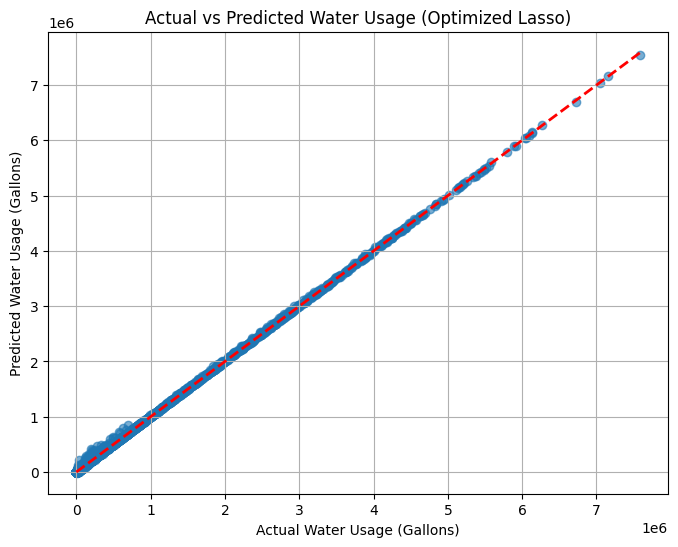

In [ ]:
#water
best_water_pred = best_lasso_water.predict(X_test_scaled)

plt.figure(figsize=(8,6))
plt.scatter(y_test_water, best_water_pred, alpha=0.6)

# Perfect prediction line
plt.plot([y_test_water.min(), y_test_water.max()], [y_test_water.min(), y_test_water.max()], 'r--', linewidth=2)

plt.xlabel("Actual Water Usage (Gallons)")
plt.ylabel("Predicted Water Usage (Gallons)")
plt.title("Actual vs Predicted Water Usage (Optimized Lasso)")
plt.grid(True)

plt.show()

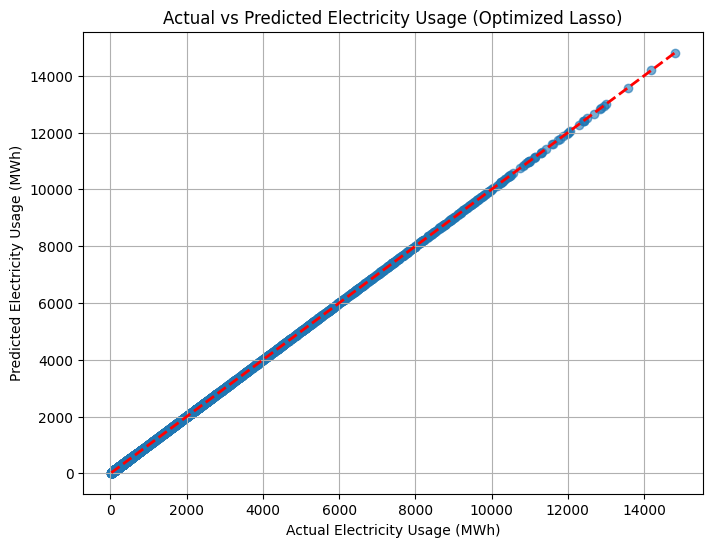

In [ ]:
best_elec_pred = best_lasso_elec.predict(X_test_scaled)

plt.figure(figsize=(8,6))
plt.scatter(y_test_elec, best_elec_pred, alpha=0.6)

plt.plot([y_test_elec.min(), y_test_elec.max()], [y_test_elec.min(), y_test_elec.max()], 'r--', linewidth=2)

plt.xlabel("Actual Electricity Usage (MWh)")
plt.ylabel("Predicted Electricity Usage (MWh)")
plt.title("Actual vs Predicted Electricity Usage (Optimized Lasso)")
plt.grid(True)

plt.show()

Observations:

- The Overall Trend Captured Well

The predicted values follow the same general upward trend as the water and electricity usage, showing how it's linear which is consistent with how data centers work

- The Close Alignment Between Lines

For most of the timeline, the predicted curve stays very close to the actual usage, which suggests that the model provides reasonably accurate predictions and captures the underlying structure of the data.

- The Consistent Model Behavior

The predictions do not diverge significantly from actual usage over time, indicating stable model performance and good generalization across the test dataset.

24. Plotting Residuals

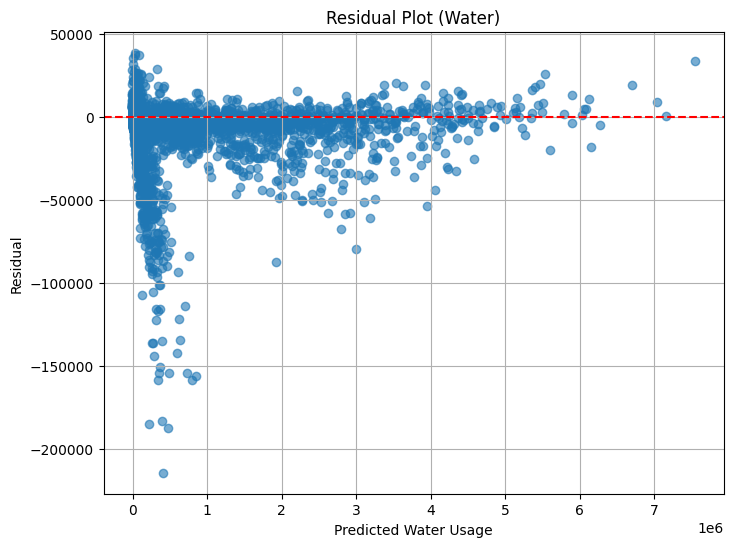

In [ ]:
water_residuals = y_test_water - best_water_pred

plt.figure(figsize=(8,6))
plt.scatter(best_water_pred, water_residuals, alpha=0.6)

plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Predicted Water Usage")
plt.ylabel("Residual")
plt.title("Residual Plot (Water)")
plt.grid(True)

plt.show()

Observations: Many residuals are gathered near 0, which suggests mostly accurate predictions. However, a huge negative trend for lower predictions and higher scattered residuals for higher predictions may imply that predictions are less consistent for very low or high values, and tend to overestimate lower values and occasionally underestimate higher values.

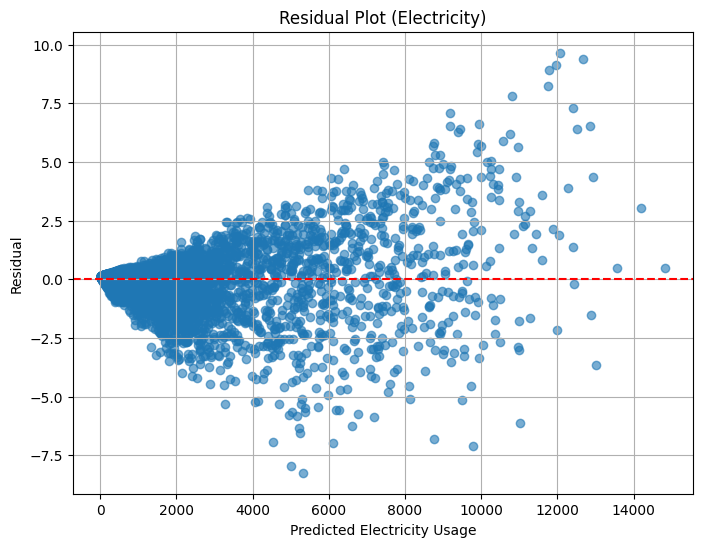

In [ ]:
elec_residuals = y_test_elec - best_elec_pred

plt.figure(figsize=(8,6))
plt.scatter(best_elec_pred, elec_residuals, alpha=0.6)

plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Predicted Electricity Usage")
plt.ylabel("Residual")
plt.title("Residual Plot (Electricity)")
plt.grid(True)

plt.show()

Observations:
The electricity residuals also clutter near 0, but while they seem more spread out overall, the magnitude is much smaller. Lower predictions are much more tightly clustered near 0 which suggest high accuracy, the spread widens as predicted electricity increase, becoming less consistent or reliable for higher electricity consumption. This indicates heteroscedasticity, where the variance of the errors increases with the predicted value.

Residual Distributions

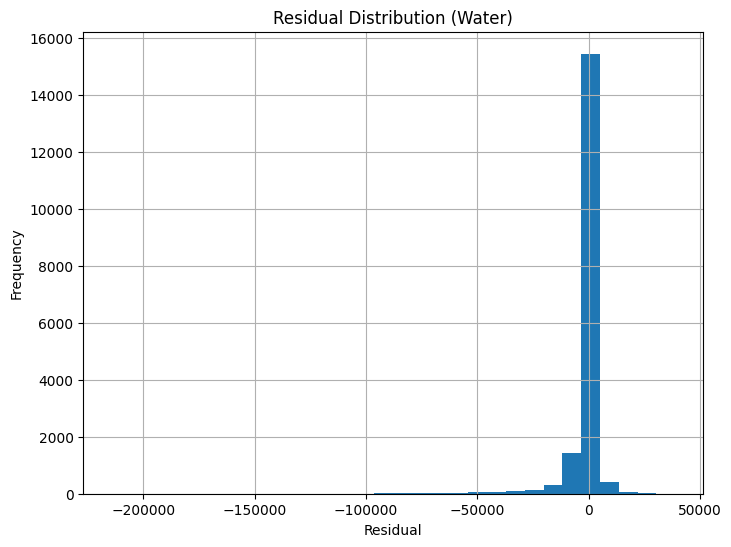

In [ ]:
plt.figure(figsize=(8,6))

plt.hist(water_residuals, bins=30)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution (Water)")

plt.grid(True)

plt.show()

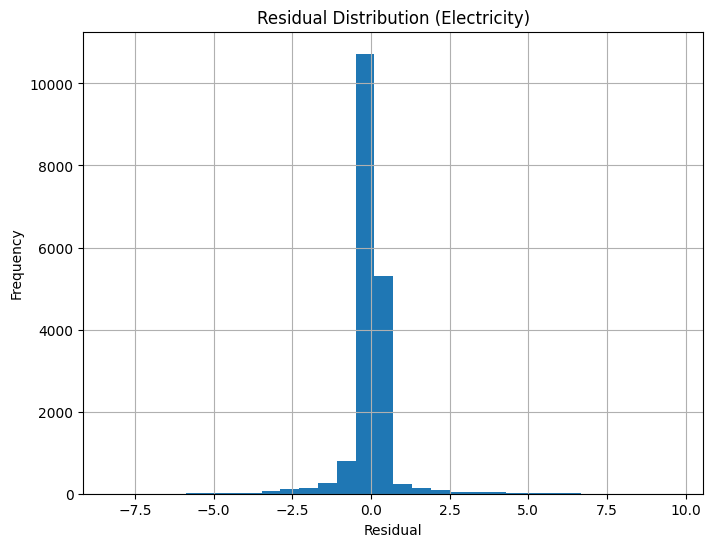

In [ ]:
plt.figure(figsize=(8,6))

plt.hist(elec_residuals, bins=30)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution (Electricity)")

plt.grid(True)

plt.show()

Observations:
The histogram distributions are consistent with the scatterplot, showing the majority of residuals being near 0 with some spread out but with much less frequency.

25. Feature Importance

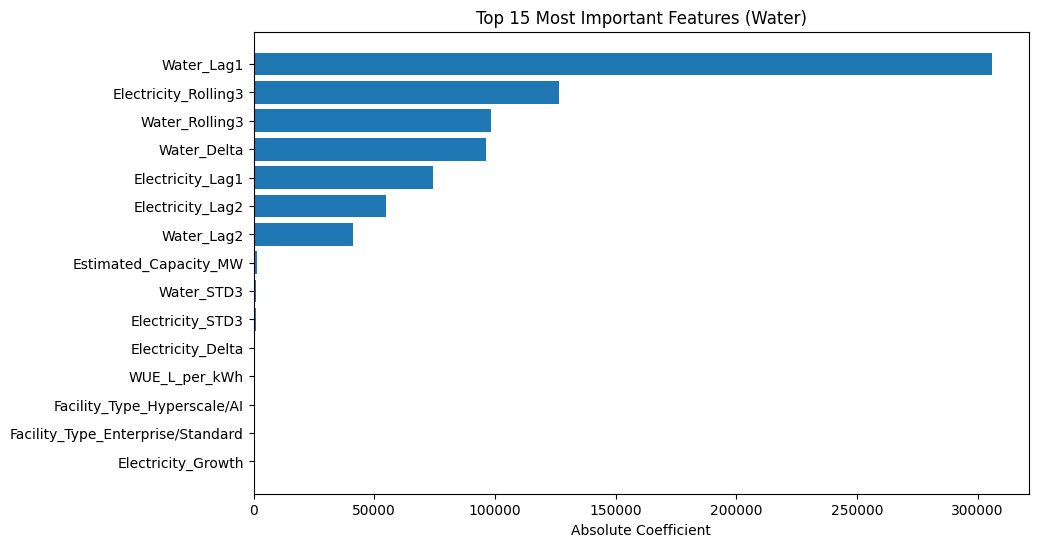

In [ ]:
#water
water_feature_importance = pd.DataFrame({"Feature": X_train_encoded.columns, "Importance": abs(best_lasso_water.coef_)})

water_feature_importance = water_feature_importance.sort_values(by="Importance", ascending=False).head(15)

plt.figure(figsize=(10,6))

plt.barh(water_feature_importance["Feature"], water_feature_importance["Importance"])

plt.gca().invert_yaxis()

plt.xlabel("Absolute Coefficient")
plt.title("Top 15 Most Important Features (Water)")

plt.show()

Observations: Model coefficients are used to measure feature importance due to Lasso Regression not having built-in feature importance. Water_Lag1 is the clear most used feature for training suggesting past water usage is a string predictor for current water usage, with Electricity Rolling 3, Water Rolling 3, and Water Delta also showing high importance, suggesting that recent trends and changes in both electricity and water usage are important. Electricity Lag 1 and 2 also have a role albeit a smaller one, which supports the notion that electricity usage can help predict water usage.

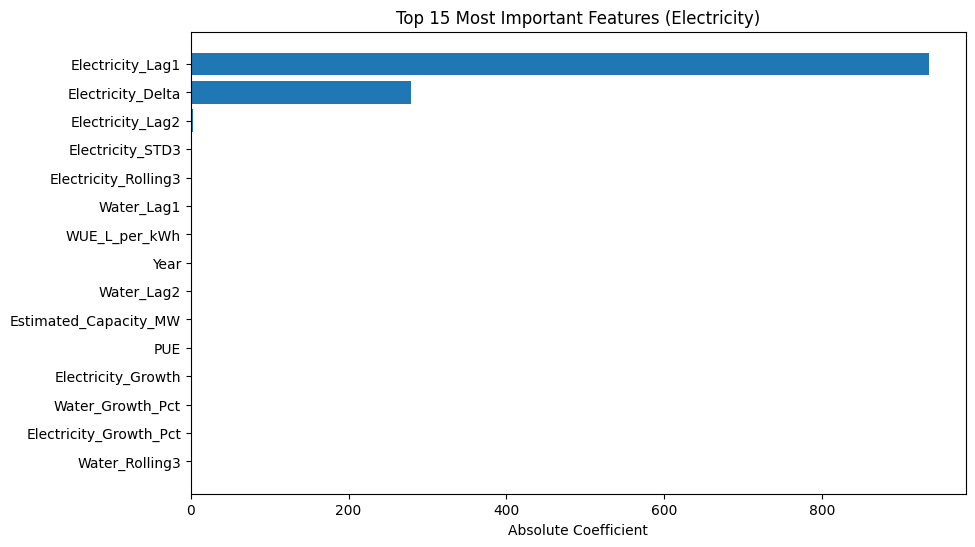

In [ ]:
#Electricity
elec_feature_importance = pd.DataFrame({"Feature": X_train_encoded.columns, "Importance": abs(best_lasso_elec.coef_)})

elec_feature_importance = elec_feature_importance.sort_values(by="Importance", ascending=False).head(15)

plt.figure(figsize=(10,6))

plt.barh(elec_feature_importance["Feature"], elec_feature_importance["Importance"])

plt.gca().invert_yaxis()

plt.xlabel("Absolute Coefficient")
plt.title("Top 15 Most Important Features (Electricity)")

plt.show()

Observations: Electricity_Lag1 is by far the most used feature, which suggests past electricity consumption is the strongest predictor for current electricity usage. Electricity_Delta is the second most important feature, with Electricity_Lag2, Electricity_STD3, and Electricity_Rolling3 also showing moderate importance, suggesting that previous electricity consumption patterns are looked at as well. The rest have small importance in comparison

26. Plotting Learning Curve

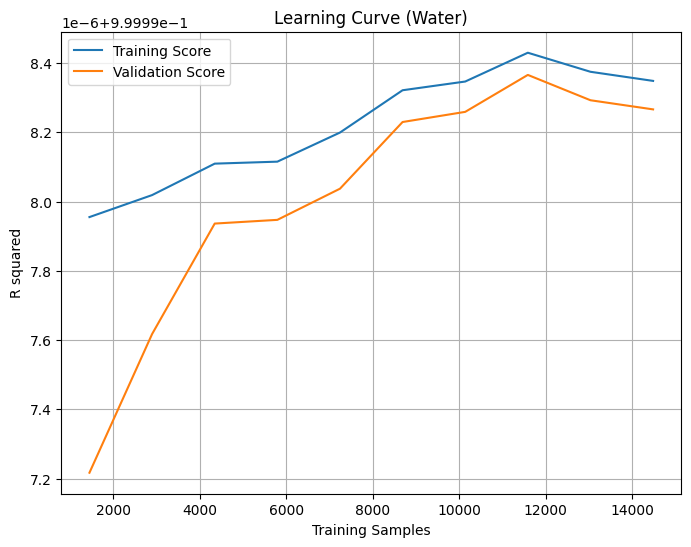

In [ ]:
from sklearn.model_selection import learning_curve

water_train_sizes, water_train_scores, water_test_scores = learning_curve(best_lasso_water, X_train_scaled, y_train_water, cv=5, scoring='r2', train_sizes=np.linspace(0.1,1.0,10), n_jobs=-1)

plt.figure(figsize=(8,6))

plt.plot(water_train_sizes, water_train_scores.mean(axis=1), label='Training Score')

plt.plot(water_train_sizes, water_test_scores.mean(axis=1), label='Validation Score')

plt.xlabel("Training Samples")
plt.ylabel("R squared")

plt.title("Learning Curve (Water)")

plt.legend()

plt.grid(True)

plt.show()

Observations:
The training score is consistently high and slightly increases as it trains more data, with the validation score having a sharper increase with more training data and getting closer to training score. This suggests that the model benefits from more data and is generalizing better as the training size grows. Both curves seem to be getting close to a high R-squared value, which indicates that the model is performing well with low bias and low variance.


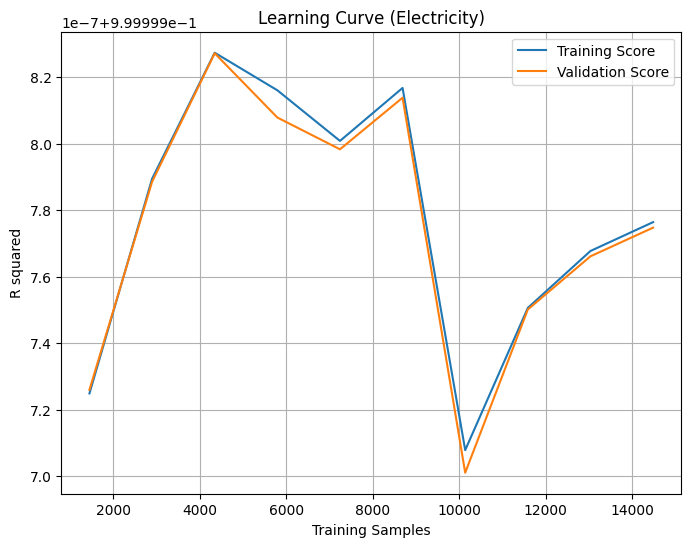

In [ ]:
elec_train_sizes, elec_train_scores, elec_test_scores = learning_curve(best_lasso_elec, X_train_scaled, y_train_elec, cv=5, scoring='r2', train_sizes=np.linspace(0.1,1.0,10), n_jobs=-1)

plt.figure(figsize=(8,6))

plt.plot(elec_train_sizes, elec_train_scores.mean(axis=1), label='Training Score')

plt.plot(elec_train_sizes, elec_test_scores.mean(axis=1), label='Validation Score')

plt.xlabel("Training Samples")
plt.ylabel("R squared")

plt.title("Learning Curve (Electricity)")

plt.legend()

plt.grid(True)

plt.show()

Observations:
There is a high initial performance at about 4200-4500 samples, which indicates the model learned and fitted the data quickly; however, both scores dropped since then before peaking again with a sharped decline in R squared which could indicate instability of sensitivity. Throughout the curve, the training and validation scores remain very close to each other, suggesting that the model has low bias and generalizes well to unseen data. Despite the fluctuation, both curves are consistently at a very high R-squared value.

27. Error Metrics Summary

In [ ]:
summary_water = pd.DataFrame({"Metric":["MAE","RMSE","R squared"], "Value":[mean_absolute_error(y_test_water, lasso_water_pred), np.sqrt(mean_squared_error(y_test_water, lasso_water_pred)), r2_score(y_test_water, lasso_water_pred)]})

display(summary_water)

,Metric,Value
0,MAE,3081.001656
1,RMSE,9564.904170
2,R squared,0.999714


In [ ]:
summary_elec = pd.DataFrame({"Metric":["MAE","RMSE","R squared"], "Value":[mean_absolute_error(y_test_elec, lasso_elec_pred), np.sqrt(mean_squared_error(y_test_elec, lasso_elec_pred)), r2_score(y_test_elec, lasso_elec_pred)]})

display(summary_elec)

,Metric,Value
0,MAE,0.328951
1,RMSE,1.074710
2,R squared,0.999999


28. Future Trend Prediction; requires a new future dataset so many steps will be repeated

Creating a Future Dataset

In [ ]:
future_years = [2026, 2027, 2028, 2029, 2030]

future_rows = []

# Last observation from every facility
last_records = (df.sort_values(['Facility_ID', 'Year']).groupby('Facility_ID').last().reset_index())

for _, row in last_records.iterrows():

    for year in future_years:

        new_row = row.copy()

        new_row['Year'] = year

        future_rows.append(new_row)

future_df = pd.DataFrame(future_rows)

future_df.head()

,Facility_ID,Year,City,Country,Facility_Type,Estimated_Capacity_MW,PUE,Cooling_System_Type,WUE_L_per_kWh,Daily_Electricity_Usage_MWh,...,Electricity_Growth,Water_Growth,Electricity_Growth_Pct,Water_Growth_Pct,Electricity_Rolling3,Water_Rolling3,Electricity_STD3,Water_STD3,Electricity_Delta,Water_Delta
0,DC-0006E5D5,2026,Giza,Egypt,Enterprise/Standard,5.54,1.466,Evaporative,1.473,171.47,...,0.035885,0.026066,3.588473,2.606649,163.64,43899.26,13.494632,3324.539875,5.94,1155.8
0,DC-0006E5D5,2027,Giza,Egypt,Enterprise/Standard,5.54,1.466,Evaporative,1.473,171.47,...,0.035885,0.026066,3.588473,2.606649,163.64,43899.26,13.494632,3324.539875,5.94,1155.8
0,DC-0006E5D5,2028,Giza,Egypt,Enterprise/Standard,5.54,1.466,Evaporative,1.473,171.47,...,0.035885,0.026066,3.588473,2.606649,163.64,43899.26,13.494632,3324.539875,5.94,1155.8
0,DC-0006E5D5,2029,Giza,Egypt,Enterprise/Standard,5.54,1.466,Evaporative,1.473,171.47,...,0.035885,0.026066,3.588473,2.606649,163.64,43899.26,13.494632,3324.539875,5.94,1155.8
0,DC-0006E5D5,2030,Giza,Egypt,Enterprise/Standard,5.54,1.466,Evaporative,1.473,171.47,...,0.035885,0.026066,3.588473,2.606649,163.64,43899.26,13.494632,3324.539875,5.94,1155.8


Combining Historical & Future Data

In [ ]:
combined_df = pd.concat([df, future_df], ignore_index=True)

combined_df = combined_df.sort_values(['Facility_ID', 'Year'])

Creating Lag Features, Rolling Averages, & Rolling Standard Devaitions

In [ ]:
# 1-year lag features
combined_df['Water_Lag1'] = (combined_df.groupby('Facility_ID')['Daily_Water_Usage_Gallons'].shift(1))
combined_df['Electricity_Lag1'] = (combined_df.groupby('Facility_ID')['Daily_Electricity_Usage_MWh'].shift(1))

# 2-year lag features
combined_df['Water_Lag2'] = (combined_df.groupby('Facility_ID')['Daily_Water_Usage_Gallons'].shift(2))
combined_df['Electricity_Lag2'] = (combined_df.groupby('Facility_ID')['Daily_Electricity_Usage_MWh'].shift(2))

# Year-over-year changes
combined_df['Water_Growth'] = (combined_df.groupby('Facility_ID')['Daily_Water_Usage_Gallons'].pct_change())
combined_df['Electricity_Growth'] = (combined_df.groupby('Facility_ID')['Daily_Electricity_Usage_MWh'].pct_change())

In [ ]:
#Rolling Averages
combined_df['Water_Rolling3'] = (combined_df.groupby('Facility_ID')['Daily_Water_Usage_Gallons'].transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean()))
combined_df['Electricity_Rolling3'] = (combined_df.groupby('Facility_ID')['Daily_Electricity_Usage_MWh'].transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean()))

In [ ]:
#Rolling Standard Deviations
combined_df['Water_RollingStd3'] = (combined_df.groupby('Facility_ID')['Daily_Water_Usage_Gallons'].transform(lambda x: x.shift(1).rolling(3).std()))
combined_df['Electricity_RollingStd3'] = (combined_df.groupby('Facility_ID')['Daily_Electricity_Usage_MWh'].transform(lambda x: x.shift(1).rolling(3).std()))

Growth Rate

In [ ]:
combined_df['Water_Growth'] = (combined_df.groupby('Facility_ID')['Daily_Water_Usage_Gallons'].pct_change())
combined_df['Electricity_Growth'] = (combined_df.groupby('Facility_ID')['Daily_Electricity_Usage_MWh'].pct_change())

Keep Only Future Rows

In [ ]:
future_df = combined_df[combined_df['Year'].isin(future_years)].copy()

Dropping Target Variables

In [ ]:
future_features = future_df.drop(columns=['Water_Usage', 'Electricity_Usage'], errors='ignore')

One-Hot Encoding

In [ ]:
future_features = pd.get_dummies(future_features, drop_first=True)

future_features = future_features.reindex(columns=X_train_encoded.columns, fill_value=0)

Scale Features for Lasso Regression

In [ ]:
future_scaled = scaler.transform(future_features)

Predict Future Values

In [ ]:
future_df['Predicted_Water'] = (best_lasso_water.predict(future_scaled))

In [ ]:
future_df['Predicted_Electricity'] = (best_lasso_elec.predict(future_scaled))

Plotting Trends

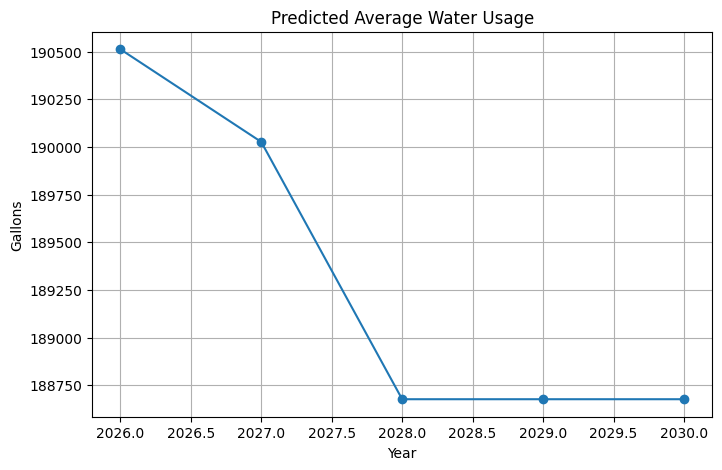

In [ ]:
water_yearly = (future_df.groupby('Year')['Predicted_Water'].mean())

plt.figure(figsize=(8,5))

plt.plot(water_yearly.index, water_yearly.values, marker='o')

plt.title("Predicted Average Water Usage")
plt.xlabel("Year")
plt.ylabel("Gallons")

plt.grid(True)

plt.show()

Observations: The predictions have a notable decrease between 2026 & 2028, but stabilizes afterwards. However, the usage is still really high and concerning for many people.

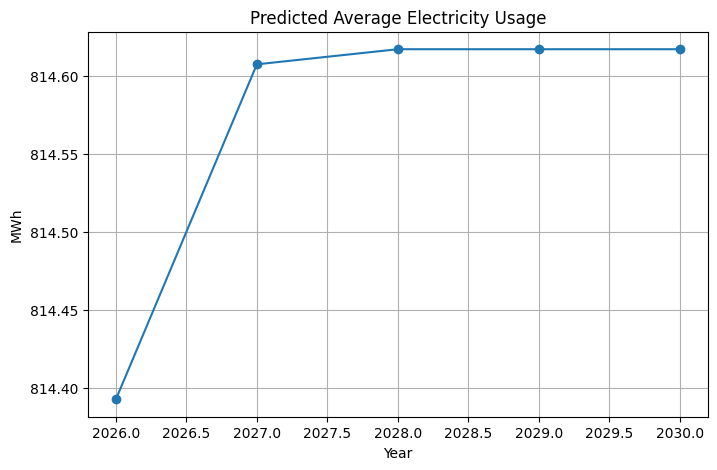

In [ ]:
electricity_yearly = (future_df.groupby('Year')['Predicted_Electricity'].mean())

plt.figure(figsize=(8,5))

plt.plot(electricity_yearly.index, electricity_yearly.values, marker='o')

plt.title("Predicted Average Electricity Usage")
plt.xlabel("Year")
plt.ylabel("MWh")

plt.grid(True)

plt.show()

Observations:
There's an overall small increase in usage between 2026 & 2027, but it mostly stabilizes afterwards.